In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats
from matplotlib.patches import Ellipse
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv("intelligent_streetlight_dataset.csv")
data.head(10)

,Timestamp,Street ID,Day/Night,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Weather,Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend
0,2024-01-21 05:27:00,8,Day,154,41.750173,59.383884,172.439065,Clear,0.37,1,50,40.877092,-73.813538,1,0
1,2024-01-11 12:15:00,3,Night,103,30.949961,24.208586,189.339042,Rainy,0.00,0,100,40.862553,-74.125943,0,0
2,2024-01-29 20:18:00,9,Night,203,32.089607,29.733312,200.236036,Cloudy,0.00,0,75,40.809826,-73.853724,1,0
3,2024-01-05 13:42:00,5,Day,161,27.758249,27.850047,197.078404,Cloudy,0.78,1,100,40.529601,-74.073302,0,0
4,2024-01-08 07:45:00,1,Night,55,41.492456,59.282133,279.109775,Clear,0.46,1,50,40.565817,-74.116742,1,1
5,2024-01-26 17:13:00,6,Night,200,28.293919,23.986351,226.654123,Cloudy,0.83,1,100,40.728570,-73.859139,0,0
6,2024-01-15 17:21:00,2,Day,244,26.971331,48.980259,137.154322,Clear,0.00,0,50,40.751900,-73.771091,0,0
7,2024-01-12 04:06:00,6,Day,228,16.025011,46.700969,34.368789,Cloudy,0.43,1,100,40.552163,-74.166822,1,0
8,2024-01-10 17:16:00,1,Day,51,31.692600,58.172359,85.197577,Clear,0.00,0,75,40.569960,-73.884714,0,0
9,2024-01-23 08:54:00,1,Day,81,55.383021,47.332112,66.610264,Clear,0.00,0,100,40.603965,-74.059541,0,1


In [166]:
data.describe()

,Street ID,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.508000,177.429000,35.047700,39.891310,171.234179,0.241780,0.503000,49.225000,40.702442,-73.946743,0.459000,0.498000
std,2.909364,70.064756,14.647251,11.603187,101.865321,0.291477,0.500241,35.969684,0.115534,0.142642,0.498566,0.500246
min,1.000000,50.000000,10.073398,20.036734,0.078170,0.000000,0.000000,0.000000,40.500899,-74.198446,0.000000,0.000000
25%,3.000000,118.000000,22.296820,29.682256,81.068828,0.000000,0.000000,25.000000,40.605432,-74.072035,0.000000,0.000000
50%,5.000000,179.000000,35.566512,39.294904,167.424778,0.075000,1.000000,50.000000,40.704036,-73.939872,0.000000,0.000000
75%,8.000000,237.250000,47.676395,49.999874,255.746741,0.460000,1.000000,75.000000,40.803821,-73.823415,1.000000,1.000000
max,10.000000,299.000000,59.993186,59.993270,349.747146,1.360000,1.000000,100.000000,40.899189,-73.700907,1.000000,1.000000


In [167]:
# Convert to relative time measurement from the t0, format YYYY-MM-DD HH:mm:ss.######
data["Timestamp"] = pd.to_datetime(
    data["Timestamp"],
    format="%Y-%m-%d %H:%M:%S"
)
data = data.sort_values(['Timestamp'])

t0 = data["Timestamp"].iloc[0]
data["Time Seconds"] = (data["Timestamp"] - t0).dt.total_seconds().astype(int)
data["Day Type"] = np.where(
    (data["Special Event"] == 0) & (data["Holiday/Weekend"] == 0),
    "Regular Day",
    "Event/Holiday/Weekend"
)
data.head(10)

,Timestamp,Street ID,Day/Night,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Weather,Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend,Time Seconds,Day Type
888,2024-01-01 00:13:00,4,Day,138,13.598167,42.184218,279.524143,Cloudy,0.00,0,75,40.629837,-74.021929,0,0,0,Regular Day
171,2024-01-01 00:21:00,6,Night,245,43.463640,23.873559,232.828946,Cloudy,0.90,1,100,40.649818,-74.032941,1,0,480,Event/Holiday/Weekend
586,2024-01-01 00:27:00,6,Night,96,46.103635,32.763675,68.878547,Rainy,0.18,1,75,40.897741,-73.939575,1,0,840,Event/Holiday/Weekend
360,2024-01-01 01:12:00,1,Night,211,45.825175,41.935423,172.657189,Clear,0.83,1,100,40.813486,-73.704274,1,0,3540,Event/Holiday/Weekend
849,2024-01-01 01:16:00,2,Night,262,12.700400,37.043547,265.588667,Clear,0.00,0,100,40.842534,-74.127582,1,0,3780,Event/Holiday/Weekend
152,2024-01-01 02:01:00,1,Day,55,28.241318,33.270998,276.910703,Rainy,0.00,0,0,40.709789,-73.959275,1,0,6480,Event/Holiday/Weekend
180,2024-01-01 02:58:00,2,Night,147,29.174147,46.317485,7.878488,Cloudy,0.00,0,75,40.809281,-73.832620,0,0,9900,Regular Day
43,2024-01-01 03:00:00,7,Night,229,25.151012,30.863811,205.705168,Cloudy,0.55,1,75,40.856372,-73.880830,1,0,10020,Event/Holiday/Weekend
199,2024-01-01 04:17:00,5,Night,153,30.793542,53.842745,218.676551,Clear,0.44,1,75,40.645602,-73.838843,1,1,14640,Event/Holiday/Weekend
540,2024-01-01 04:29:00,6,Night,174,18.032232,26.963304,223.167569,Clear,0.00,0,50,40.693682,-73.977515,1,0,15360,Event/Holiday/Weekend


In [168]:
# Unique value of "Steet ID" -> # samples, # Special Event, # Holiday/Weekend, # Special Holiday/Weekend, # Regualr Days, # Non-Regular Days
street_ids = sorted(data['Street ID'].unique())

t1 = pd.DataFrame([
    {
        'Street ID': street_id,
        '# samples': len(data[data['Street ID'] == street_id]),
        '# Special Events': (data[data['Street ID'] == street_id]['Special Event'] == 1).sum(),
        '# Holidays/Weekends': (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1).sum(),
        '# Special Holidays/Weekends': ((data[data['Street ID'] == street_id]['Special Event'] == 1) & 
                                        (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum(),
        '# Regular Days': ((data[data['Street ID'] == street_id]['Special Event'] == 0) & 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 0)).sum(),
        '# Events/Holidays/Weekends': ((data[data['Street ID'] == street_id]['Special Event'] == 1) | 
                                      (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum(),
        '% Regular Days': round(((data[data['Street ID'] == street_id]['Special Event'] == 0) & 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 0)).sum()/len(data[data['Street ID'] == street_id])*100, 2),
        '% Events/Holidays/Weekends': round(((data[data['Street ID'] == street_id]['Special Event'] == 1) | 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum()/len(data[data['Street ID'] == street_id])*100,2)
    }
    for street_id in street_ids
])

t1

,Street ID,# samples,# Special Events,# Holidays/Weekends,# Special Holidays/Weekends,# Regular Days,# Events/Holidays/Weekends,% Regular Days,% Events/Holidays/Weekends
0,1,103,47,54,23,25,78,24.27,75.73
1,2,100,53,44,22,25,75,25.00,75.00
2,3,106,49,56,24,25,81,23.58,76.42
3,4,97,46,50,26,27,70,27.84,72.16
4,5,95,51,42,24,26,69,27.37,72.63
5,6,90,43,50,23,20,70,22.22,77.78
6,7,97,42,48,25,32,65,32.99,67.01
7,8,101,47,45,22,31,70,30.69,69.31
8,9,113,47,55,24,35,78,30.97,69.03
9,10,98,34,54,16,26,72,26.53,73.47


HYPOTHESIS TEST: Does Power State = 0 mean Energy Consumption = 0?

1. BASIC DATA OVERVIEW
----------------------------------------
Unique Power State values: [0 1]
Data type of Power State: int64
                 # Samples  % of Total  Avg Energy (kWh)  Min Energy (kWh)  \
Power State = 0        497        49.7             0.000              0.00   
Power State ≠ 0        503        50.3             0.481              0.07   
Total                 1000       100.0             0.242              0.00   

                 Max Energy (kWh)  # Energy = 0  # Energy > 0  % Energy = 0  \
Power State = 0              0.00           497             0         100.0   
Power State ≠ 0              1.36             0           503           0.0   
Total                        1.36           497           503           NaN   

                 % Energy > 0  
Power State = 0           0.0  
Power State ≠ 0         100.0  
Total                     NaN  


2. CONTINGENCY TABLE ANALYSIS
-------------

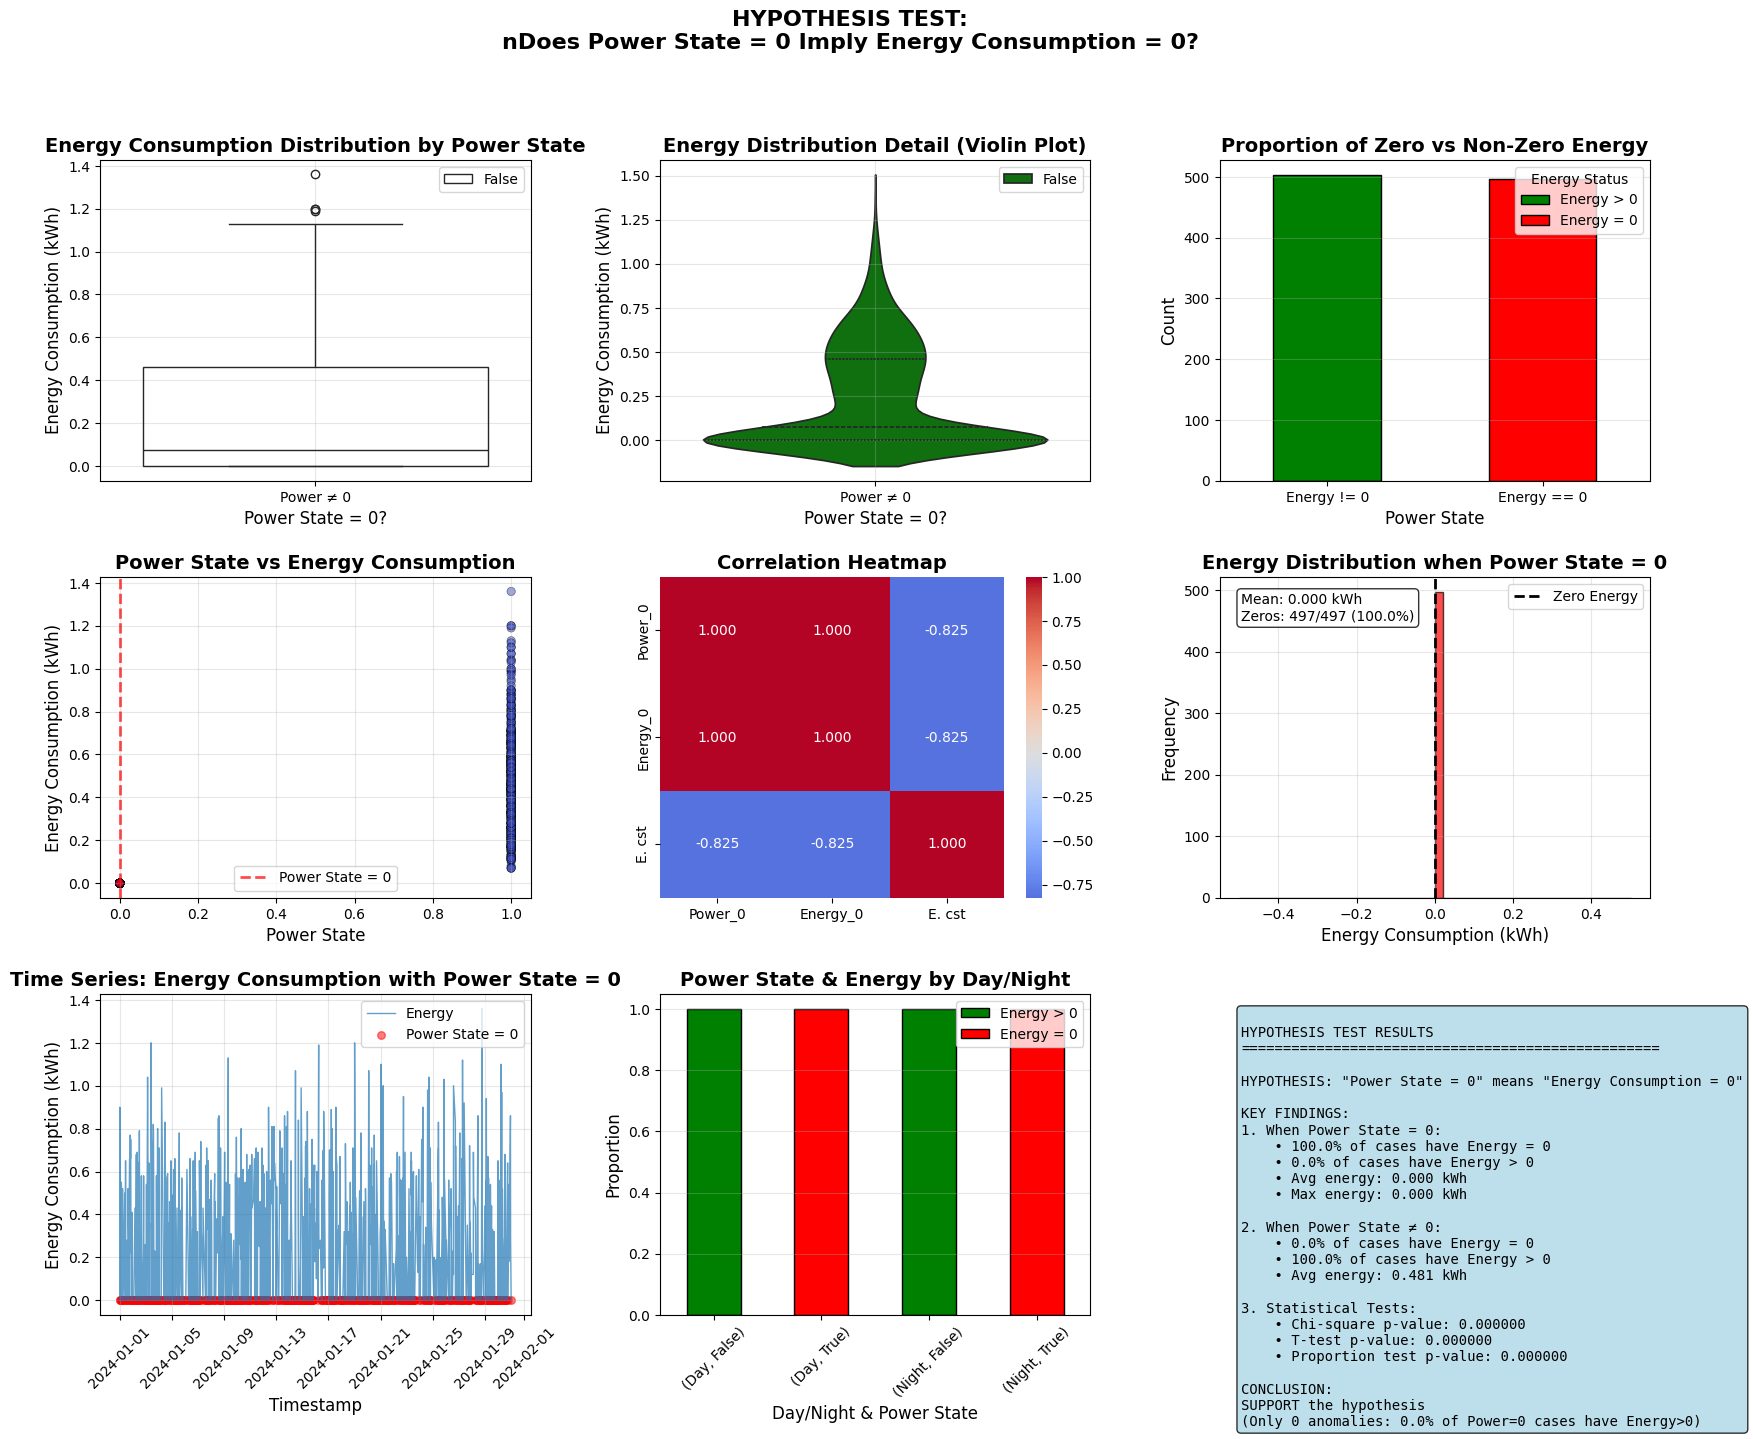



5. ANOMALY ANALYSIS
----------------------------------------
Number of anomalies found: 0
Percentage of Power=0 cases that are anomalies: 0.00%


6. FINAL CONCLUSION

Hypothesis: 'Power State = 0' means 'Energy Consumption (kWh) = 0'

Evidence:
  1. When Power State = 0, 100.0% of cases have Energy = 0
  2. 0 anomalies found where Power=0 but Energy>0
  3. Anomaly rate: 0.0% of Power=0 cases

HYPOTHESIS IS LARGELY SUPPORTED
   Only 0.0% exceptions (within acceptable margin)


In [169]:
# Check if Power State column exists
print("="*80)
print("HYPOTHESIS TEST: Does Power State = 0 mean Energy Consumption = 0?")
print("="*80)

# 1. Basic Analysis
print("\n1. BASIC DATA OVERVIEW")
print("-"*40)

# Check unique values in Power State
print(f"Unique Power State values: {data['Power State'].unique()}")
print(f"Data type of Power State: {data['Power State'].dtype}")

# Convert to numeric if needed
if data['Power State'].dtype == 'object':
    print("Power State is categorical. Converting to numeric...")
    data['Power State_numeric'] = pd.to_numeric(data['Power State'], errors='coerce')
    power_col = 'Power State_numeric'
else:
    power_col = 'Power State'

# Create summary table
hypothesis_summary = pd.DataFrame(index=['Power State = 0', 'Power State ≠ 0', 'Total'])

# Count samples in each category
power_zero_mask = data[power_col] == 0
power_nonzero_mask = data[power_col] != 0

hypothesis_summary['# Samples'] = [
    power_zero_mask.sum(),
    power_nonzero_mask.sum(),
    len(data)
]

hypothesis_summary['% of Total'] = [
    power_zero_mask.sum() / len(data) * 100,
    power_nonzero_mask.sum() / len(data) * 100,
    100
]

# Energy consumption analysis
hypothesis_summary['Avg Energy (kWh)'] = [
    data.loc[power_zero_mask, 'Energy Consumption (kWh)'].mean(),
    data.loc[power_nonzero_mask, 'Energy Consumption (kWh)'].mean(),
    data['Energy Consumption (kWh)'].mean()
]

hypothesis_summary['Min Energy (kWh)'] = [
    data.loc[power_zero_mask, 'Energy Consumption (kWh)'].min(),
    data.loc[power_nonzero_mask, 'Energy Consumption (kWh)'].min(),
    data['Energy Consumption (kWh)'].min()
]

hypothesis_summary['Max Energy (kWh)'] = [
    data.loc[power_zero_mask, 'Energy Consumption (kWh)'].max(),
    data.loc[power_nonzero_mask, 'Energy Consumption (kWh)'].max(),
    data['Energy Consumption (kWh)'].max()
]

# Count zeros in energy consumption
energy_zero_mask = data['Energy Consumption (kWh)'] == 0

hypothesis_summary['# Energy = 0'] = [
    (power_zero_mask & energy_zero_mask).sum(),
    (power_nonzero_mask & energy_zero_mask).sum(),
    energy_zero_mask.sum()
]

hypothesis_summary['# Energy > 0'] = [
    (power_zero_mask & ~energy_zero_mask).sum(),
    (power_nonzero_mask & ~energy_zero_mask).sum(),
    (~energy_zero_mask).sum()
]

# Calculate percentages
for index in ['Power State = 0', 'Power State ≠ 0']:
    total = hypothesis_summary.loc[index, '# Samples']
    if total > 0:
        hypothesis_summary.loc[index, '% Energy = 0'] = (
            hypothesis_summary.loc[index, '# Energy = 0'] / total * 100
        )
        hypothesis_summary.loc[index, '% Energy > 0'] = (
            hypothesis_summary.loc[index, '# Energy > 0'] / total * 100
        )

print(hypothesis_summary.round(3))

# 2. Contingency Table Analysis
print("\n\n2. CONTINGENCY TABLE ANALYSIS")
print("-"*40)

# Create contingency table
contingency = pd.crosstab(
    data[power_col] == 0,
    data['Energy Consumption (kWh)'] == 0,
    margins=True
)
contingency.columns = ['Energy > 0', 'Energy = 0', 'Total']
contingency.index = ['Power ≠ 0', 'Power = 0', 'Total']

print("Contingency Table:")
print(contingency)

# Calculate expected frequencies
chi2, p_value, dof, expected = stats.chi2_contingency(contingency.iloc[:2, :2])

print(f"\nChi-square test results:")
print(f"  Chi2 statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Degrees of freedom: {dof}")
print(f"  Expected frequencies:\n{expected}")

# 3. Hypothesis Testing
print("\n\n3. HYPOTHESIS TESTING")
print("-"*40)

# Extract relevant data
power_zero_energy = data.loc[power_zero_mask, 'Energy Consumption (kWh)']
power_nonzero_energy = data.loc[power_nonzero_mask, 'Energy Consumption (kWh)']

print(f"A. T-test for Energy Consumption:")
if len(power_zero_energy) > 1 and len(power_nonzero_energy) > 1:
    t_stat, t_pval = stats.ttest_ind(power_zero_energy, power_nonzero_energy, equal_var=False)
    print(f"   T-statistic: {t_stat:.4f}")
    print(f"   p-value: {t_pval:.6f}")
    
    if t_pval < 0.05:
        print("   CONCLUSION: Energy consumption is SIGNIFICANTLY different (p < 0.05)")
    else:
        print("   CONCLUSION: No significant difference in energy consumption (p ≥ 0.05)")

print(f"\nB. Proportion Test:")
# Test if proportion of zero energy is the same in both groups
n1 = len(power_zero_energy)
n2 = len(power_nonzero_energy)
x1 = (power_zero_energy == 0).sum()
x2 = (power_nonzero_energy == 0).sum()

p1 = x1 / n1 if n1 > 0 else 0
p2 = x2 / n2 if n2 > 0 else 0

print(f"   Power = 0: {x1}/{n1} zeros ({p1*100:.2f}%)")
print(f"   Power ≠ 0: {x2}/{n2} zeros ({p2*100:.2f}%)")

# Perform proportion test
count = [x1, x2]
nobs = [n1, n2]
if n1 > 0 and n2 > 0:
    z_stat, z_pval = proportions_ztest(count, nobs)
    print(f"   Z-statistic: {z_stat:.4f}")
    print(f"   p-value: {z_pval:.6f}")
    
    if z_pval < 0.05:
        print("   CONCLUSION: Proportion of zero energy is SIGNIFICANTLY different (p < 0.05)")
    else:
        print("   CONCLUSION: No significant difference in proportion of zero energy (p ≥ 0.05)")

# 4. Create Visualizations
print("\n\n4. VISUAL ANALYSIS")
print("-"*40)

fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Subplot 1: Distribution of Energy by Power State
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=data,
    x=power_col == 0,
    y='Energy Consumption (kWh)',
    ax=ax1,
    hue=power_col == 0,
    palette={'True': 'red', 'False': 'green'}
)
ax1.set_title('Energy Consumption Distribution by Power State', fontsize=14, fontweight='bold')
ax1.set_xlabel('Power State = 0?', fontsize=12)
ax1.set_ylabel('Energy Consumption (kWh)', fontsize=12)
ax1.set_xticklabels(['Power ≠ 0', 'Power = 0'])
ax1.grid(True, alpha=0.3)

# Subplot 2: Violin plot for detailed distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.violinplot(
    data=data,
    x=power_col == 0,
    y='Energy Consumption (kWh)',
    ax=ax2,
    hue=power_col == 0,
    palette={True: 'red', False: 'green'},
    inner='quartile'
)
ax2.set_title('Energy Distribution Detail (Violin Plot)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Power State = 0?', fontsize=12)
ax2.set_ylabel('Energy Consumption (kWh)', fontsize=12)
ax2.set_xticklabels(['Power ≠ 0', 'Power = 0'])
ax2.grid(True, alpha=0.3)

# Subplot 3: Proportion of Zero Energy
ax3 = fig.add_subplot(gs[0, 2])
proportions = pd.DataFrame({
    'Category': ['Energy != 0', 'Energy == 0'],
    'Energy > 0': [n2 - x2, n1 - x1],
    'Energy = 0': [x2, x1]
})
proportions.set_index('Category').plot(kind='bar', stacked=True, ax=ax3, 
                                        color=['green', 'red'], edgecolor='black')
ax3.set_title('Proportion of Zero vs Non-Zero Energy', fontsize=14, fontweight='bold')
ax3.set_xlabel('Power State', fontsize=12)
ax3.tick_params(axis='x', labelrotation=0)
ax3.set_ylabel('Count', fontsize=12)
ax3.legend(title='Energy Status')
ax3.grid(True, alpha=0.3, axis='y')

# Subplot 4: Scatter plot of Power State vs Energy
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(
    data[power_col],
    data['Energy Consumption (kWh)'],
    alpha=0.5,
    c=data['Energy Consumption (kWh)'] == 0,
    cmap='coolwarm',
    edgecolors='black',
    linewidth=0.5
)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Power State = 0')
ax4.set_title('Power State vs Energy Consumption', fontsize=14, fontweight='bold')
ax4.set_xlabel('Power State', fontsize=12)
ax4.set_ylabel('Energy Consumption (kWh)', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.legend()

# Subplot 5: Heatmap of correlation
ax5 = fig.add_subplot(gs[1, 1])
# Create binary variables
data_binary = data.copy()
data_binary['Power_0'] = (data[power_col] == 0).astype(int)
data_binary['Energy_0'] = (data['Energy Consumption (kWh)'] == 0).astype(int)
data_binary['E. cst'] = data_binary["Energy Consumption (kWh)"]

correlation = data_binary[['Power_0', 'Energy_0', 'E. cst']].corr()
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax5)
ax5.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Subplot 6: Histogram of energy when Power State = 0
ax6 = fig.add_subplot(gs[1, 2])
power_zero_energy_hist = data.loc[power_zero_mask, 'Energy Consumption (kWh)']
ax6.hist(power_zero_energy_hist, bins=50, color='red', alpha=0.7, edgecolor='black')
ax6.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Zero Energy')
ax6.set_title('Energy Distribution when Power State = 0', fontsize=14, fontweight='bold')
ax6.set_xlabel('Energy Consumption (kWh)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.legend()
ax6.grid(True, alpha=0.3)

# Calculate and display statistics
if len(power_zero_energy_hist) > 0:
    mean_energy = power_zero_energy_hist.mean()
    zero_count = (power_zero_energy_hist == 0).sum()
    zero_pct = zero_count / len(power_zero_energy_hist) * 100
    ax6.text(0.05, 0.95, f'Mean: {mean_energy:.3f} kWh\nZeros: {zero_count}/{len(power_zero_energy_hist)} ({zero_pct:.1f}%)',
            transform=ax6.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Subplot 7: Time series analysis (if Timestamp exists)
ax7 = fig.add_subplot(gs[2, 0])
if 'Timestamp' in data.columns:
    # Sort by timestamp
    time_data = data.sort_values('Timestamp').copy()
    time_data['Power_0'] = (time_data[power_col] == 0).astype(int)
    time_data['Energy_0'] = (time_data['Energy Consumption (kWh)'] == 0).astype(int)
    
    # Plot time series
    ax7.plot(time_data['Timestamp'], time_data['Energy Consumption (kWh)'], 
            alpha=0.7, label='Energy', linewidth=1)
    ax7.scatter(time_data['Timestamp'][time_data['Power_0'] == 1], 
                time_data['Energy Consumption (kWh)'][time_data['Power_0'] == 1],
                color='red', s=30, label='Power State = 0', alpha=0.5)
    ax7.set_title('Time Series: Energy Consumption with Power State = 0', 
                    fontsize=14, fontweight='bold')
    ax7.set_xlabel('Timestamp', fontsize=12)
    ax7.set_ylabel('Energy Consumption (kWh)', fontsize=12)
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

# Subplot 8: Day/Night analysis
ax8 = fig.add_subplot(gs[2, 1])
if 'Day/Night' in data.columns:
    day_night_analysis = pd.crosstab(
        [data['Day/Night'], data[power_col] == 0],
        data['Energy Consumption (kWh)'] == 0,
        normalize='index'
    )
    day_night_analysis.plot(kind='bar', stacked=True, ax=ax8, 
                            color=['green', 'red'], edgecolor='black')
    ax8.set_title('Power State & Energy by Day/Night', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Day/Night & Power State', fontsize=12)
    ax8.set_ylabel('Proportion', fontsize=12)
    ax8.legend(['Energy > 0', 'Energy = 0'])
    ax8.grid(True, alpha=0.3, axis='y')
    plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45)

# Subplot 9: Statistical summary
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Create summary text
summary_text = f"""
HYPOTHESIS TEST RESULTS
{'='*50}

HYPOTHESIS: "Power State = 0" means "Energy Consumption = 0"

KEY FINDINGS:
1. When Power State = 0:
    • {p1*100:.1f}% of cases have Energy = 0
    • {100-p1*100:.1f}% of cases have Energy > 0
    • Avg energy: {power_zero_energy.mean():.3f} kWh
    • Max energy: {power_zero_energy.max():.3f} kWh

2. When Power State ≠ 0:
    • {p2*100:.1f}% of cases have Energy = 0
    • {100-p2*100:.1f}% of cases have Energy > 0
    • Avg energy: {power_nonzero_energy.mean():.3f} kWh

3. Statistical Tests:
    • Chi-square p-value: {p_value:.6f}
    • T-test p-value: {t_pval if 't_pval' in locals() else 'N/A':.6f}
    • Proportion test p-value: {z_pval if 'z_pval' in locals() else 'N/A':.6f}

CONCLUSION:
"""

# Determine conclusion
anomalies = (power_zero_mask & ~energy_zero_mask).sum()
total_power_zero = power_zero_mask.sum()
anomaly_rate = anomalies / total_power_zero * 100 if total_power_zero > 0 else 0

if anomaly_rate > 5:  # More than 5% anomalies
    conclusion = f"REJECT the hypothesis\n({anomalies:,} anomalies found: {anomaly_rate:.1f}% of Power=0 cases have Energy>0)"
else:
    conclusion = f"SUPPORT the hypothesis\n(Only {anomalies:,} anomalies: {anomaly_rate:.1f}% of Power=0 cases have Energy>0)"

summary_text += conclusion

ax9.text(0.05, 0.95, summary_text, fontsize=10, fontfamily='monospace',
            verticalalignment='top', transform=ax9.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('HYPOTHESIS TEST:\nnDoes Power State = 0 Imply Energy Consumption = 0?', 
                fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# 5. Anomaly Analysis
print("\n\n5. ANOMALY ANALYSIS")
print("-"*40)

# Find anomalies (Power State = 0 but Energy > 0)
anomalies = data[power_zero_mask & ~energy_zero_mask].copy()

print(f"Number of anomalies found: {len(anomalies):,}")
print(f"Percentage of Power=0 cases that are anomalies: {len(anomalies)/power_zero_mask.sum()*100:.2f}%")

if len(anomalies) > 0:
    print(f"\nAnomaly Statistics:")
    print(f"  Energy range: {anomalies['Energy Consumption (kWh)'].min():.3f} to {anomalies['Energy Consumption (kWh)'].max():.3f} kWh")
    print(f"  Average energy: {anomalies['Energy Consumption (kWh)'].mean():.3f} kWh")
    
    if 'Day/Night' in anomalies.columns:
        print(f"\nAnomalies by Day/Night:")
        print(anomalies['Day/Night'].value_counts())
    
    if 'Street ID' in anomalies.columns:
        print(f"\nTop 5 streets with anomalies:")
        print(anomalies['Street ID'].value_counts().head())
    
    print(f"\nSample of anomalies:")
    print(anomalies[['Timestamp', 'Street ID', 'Power State', 'Energy Consumption (kWh)', 
                    'Day/Night', 'Traffic Density']].head(10))

# 6. Final Conclusion
print("\n\n6. FINAL CONCLUSION")
print("="*40)

print(f"\nHypothesis: 'Power State = 0' means 'Energy Consumption (kWh) = 0'")
print(f"\nEvidence:")
print(f"  1. When Power State = 0, {p1*100:.1f}% of cases have Energy = 0")
print(f"  2. {len(anomalies):,} anomalies found where Power=0 but Energy>0")
print(f"  3. Anomaly rate: {anomaly_rate:.1f}% of Power=0 cases")

if anomaly_rate <= 5:
    print(f"\nHYPOTHESIS IS LARGELY SUPPORTED")
    print(f"   Only {anomaly_rate:.1f}% exceptions (within acceptable margin)")
elif anomaly_rate <= 20:
    print(f"\nHYPOTHESIS HAS SIGNIFICANT EXCEPTIONS")
    print(f"   {anomaly_rate:.1f}% exceptions found - hypothesis needs qualification")
else:
    print(f"\nHYPOTHESIS IS NOT SUPPORTED")
    print(f"   {anomaly_rate:.1f}% exceptions - too many violations")

# Save anomalies for further investigation
if len(anomalies) > 0:
    anomalies.to_csv('power_energy_anomalies.csv', index=False)
    print(f"\nAnomalies saved to 'power_energy_anomalies.csv'")

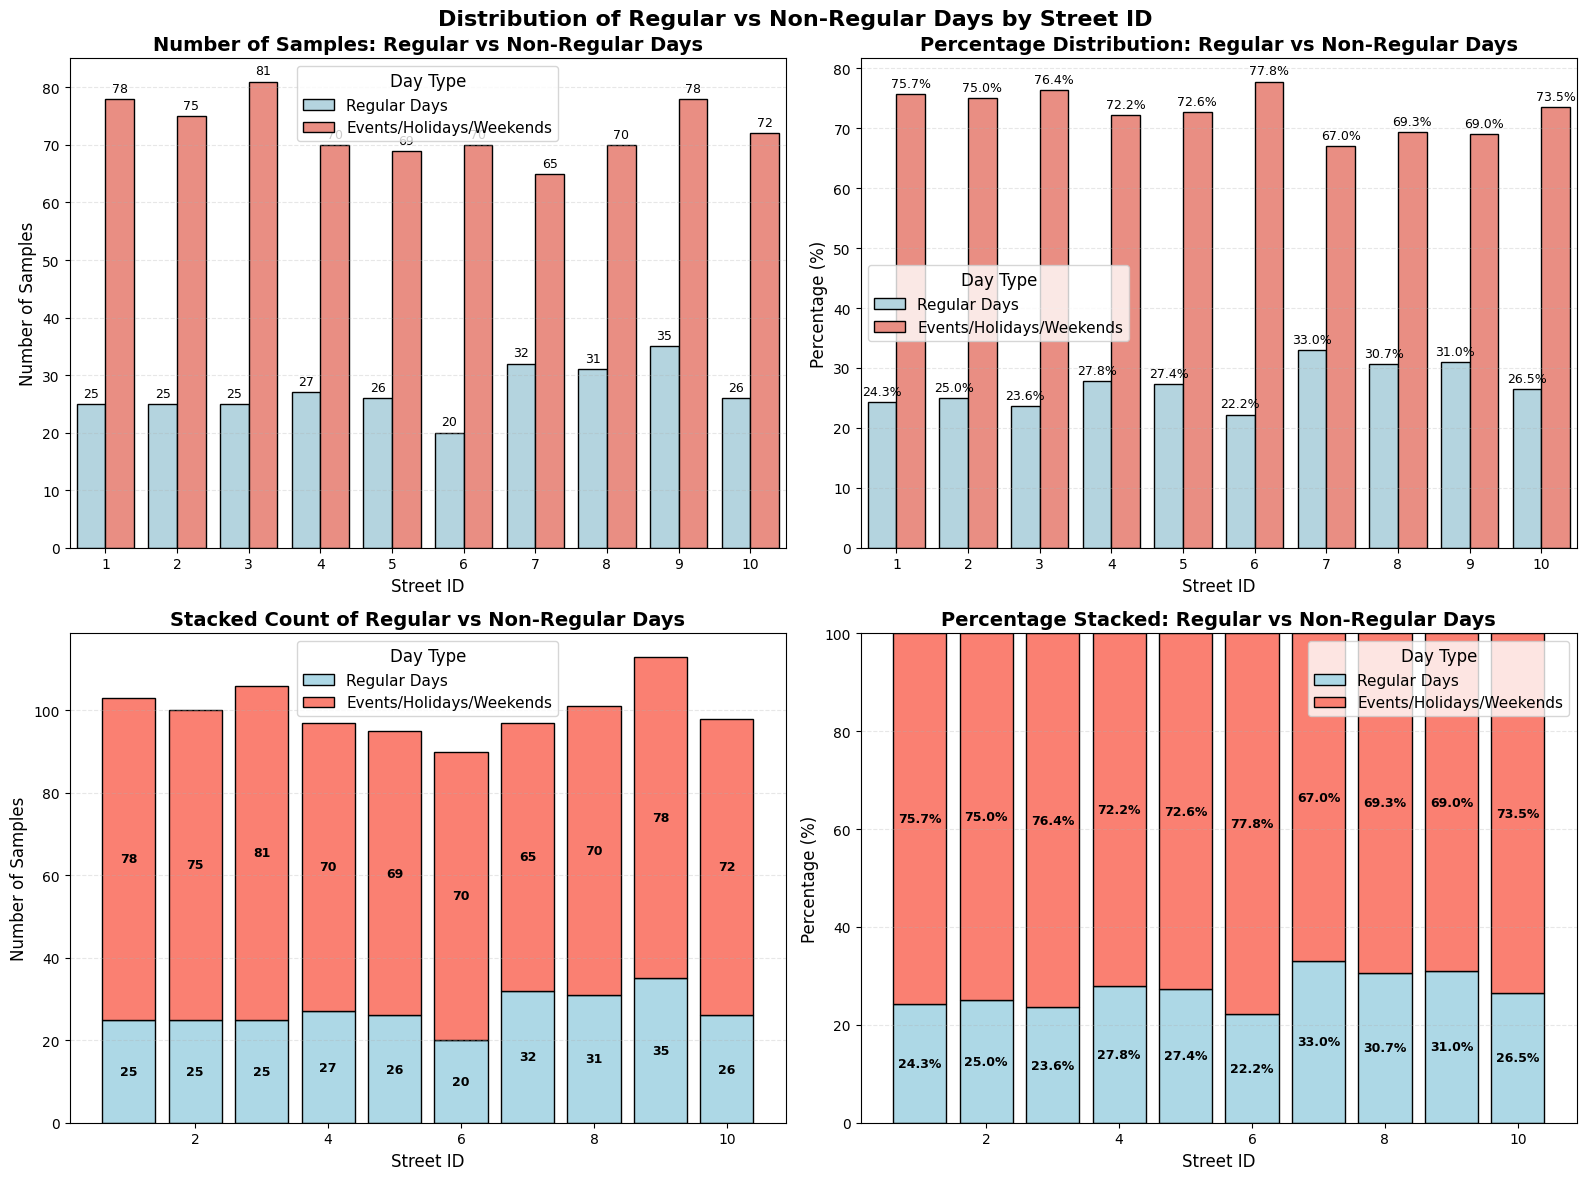


SUMMARY STATISTICS
Average Regular Days %: 27.15%
Average Events/Holidays/Weekends %: 72.85%
Street with highest Regular Days %: Street 7 (33.0%)
Street with highest Events/Holidays/Weekends %: Street 6 (77.8%)
Standard deviation of Regular Days %: 3.53%
Standard deviation of Events/Holidays/Weekends %: 3.53%


In [170]:
# 1. MELT the data for better plotting
# Create a long format for the count data
count_data = t1[['Street ID', '# Regular Days', '# Events/Holidays/Weekends']].copy()
count_data_melted = count_data.melt(
    id_vars='Street ID',
    value_vars=['# Regular Days', '# Events/Holidays/Weekends'],
    var_name='Day Type',
    value_name='Count'
)

# Create a long format for the percentage data
percent_data = t1[['Street ID', '% Regular Days', '% Events/Holidays/Weekends']].copy()
percent_data_melted = percent_data.melt(
    id_vars='Street ID',
    value_vars=['% Regular Days', '% Events/Holidays/Weekends'],
    var_name='Day Type',
    value_name='Percentage'
)

# Clean up the Day Type names
count_data_melted['Day Type'] = count_data_melted['Day Type'].str.replace('# ', '')
percent_data_melted['Day Type'] = percent_data_melted['Day Type'].str.replace('% ', '')

# 2. Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Regular vs Non-Regular Days by Street ID', fontsize=16, fontweight='bold')

# Palette for consistent coloring
palette = {'Regular Days': 'lightblue', 'Events/Holidays/Weekends': 'salmon'}

# 3. SUBPLOT 1: Count Bar Plot (Grouped)
ax1 = axes[0, 0]
sns.barplot(
    data=count_data_melted,
    x='Street ID',
    y='Count',
    hue='Day Type',
    palette=palette,
    ax=ax1,
    edgecolor='black'
)
ax1.set_title('Number of Samples: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax1.set_xlabel('Street ID', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3, fontsize=9)

# 4. SUBPLOT 2: Percentage Bar Plot (Grouped)
ax2 = axes[0, 1]
sns.barplot(
    data=percent_data_melted,
    x='Street ID',
    y='Percentage',
    hue='Day Type',
    palette=palette,
    ax=ax2,
    edgecolor='black'
)
ax2.set_title('Percentage Distribution: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax2.set_xlabel('Street ID', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

# 5. SUBPLOT 3: Count Stacked Bar Plot
# Prepare data for stacked bar
ax3 = axes[1, 0]
bar_width = 0.8
bottom_positions = np.zeros(len(t1))

# Plot stacked bars
for day_type, color in [('Regular Days', 'lightblue'), ('Events/Holidays/Weekends', 'salmon')]:
    if day_type == 'Regular Days':
        values = t1['# Regular Days']
    else:
        values = t1['# Events/Holidays/Weekends']
    
    ax3.bar(
        t1['Street ID'],
        values,
        bottom=bottom_positions,
        width=bar_width,
        color=color,
        edgecolor='black',
        label=day_type
    )
    
    # Add labels in the middle of each segment
    for i, (street_id, value) in enumerate(zip(t1['Street ID'], values)):
        if value > 0:
            y_pos = bottom_positions[i] + value/2
            ax3.text(street_id, y_pos, f'{value}', 
                    ha='center', va='center', fontweight='bold', fontsize=9)
    
    bottom_positions += values

ax3.set_title('Stacked Count of Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax3.set_xlabel('Street ID', fontsize=12)
ax3.set_ylabel('Number of Samples', fontsize=12)
ax3.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 6. SUBPLOT 4: Percentage Stacked Bar Plot
ax4 = axes[1, 1]
bottom_positions = np.zeros(len(t1))

# Plot stacked percentage bars
for day_type, color in [('Regular Days', 'lightblue'), ('Events/Holidays/Weekends', 'salmon')]:
    if day_type == 'Regular Days':
        values = t1['% Regular Days']
    else:
        values = t1['% Events/Holidays/Weekends']
    
    ax4.bar(
        t1['Street ID'],
        values,
        bottom=bottom_positions,
        width=bar_width,
        color=color,
        edgecolor='black',
        label=day_type
    )
    
    # Add percentage labels in the middle of each segment
    for i, (street_id, value) in enumerate(zip(t1['Street ID'], values)):
        if value > 1:  # Only label if percentage is significant
            y_pos = bottom_positions[i] + value/2
            ax4.text(street_id, y_pos, f'{value:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=9, color='black')
    
    bottom_positions += values

ax4.set_title('Percentage Stacked: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax4.set_xlabel('Street ID', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax4.set_ylim(0, 100)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 7. Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Average Regular Days %: {t1['% Regular Days'].mean():.2f}%")
print(f"Average Events/Holidays/Weekends %: {t1['% Events/Holidays/Weekends'].mean():.2f}%")
print(f"Street with highest Regular Days %: Street {t1.loc[t1['% Regular Days'].idxmax(), 'Street ID']} ({t1['% Regular Days'].max():.1f}%)")
print(f"Street with highest Events/Holidays/Weekends %: Street {t1.loc[t1['% Events/Holidays/Weekends'].idxmax(), 'Street ID']} ({t1['% Events/Holidays/Weekends'].max():.1f}%)")
print(f"Standard deviation of Regular Days %: {t1['% Regular Days'].std():.2f}%")
print(f"Standard deviation of Events/Holidays/Weekends %: {t1['% Events/Holidays/Weekends'].std():.2f}%")

DAY TYPE STATISTICS
                      Energy Consumption (kWh)                           \
                                          mean    std   min   max count   
Day Type                                                                  
Event/Holiday/Weekend                    0.480  0.233  0.07  1.36   368   
Regular Day                              0.482  0.231  0.07  1.07   135   

                      Ambient Light (lux)          Traffic Density          
                                     mean      std            mean     std  
Day Type                                                                    
Event/Holiday/Weekend             175.632  102.329          35.843  15.260  
Regular Day                       167.418  102.882          34.593  13.967  

DETAILED DAY TYPE ANALYSIS - STATISTICAL COMPARISON

SAMPLE COUNTS:
• Regular Days: 135 samples (26.8%)
• Event/Holiday/Weekends: 368 samples (73.2%)

ENERGY CONSUMPTION (kWh):
────────────────────────────────────────


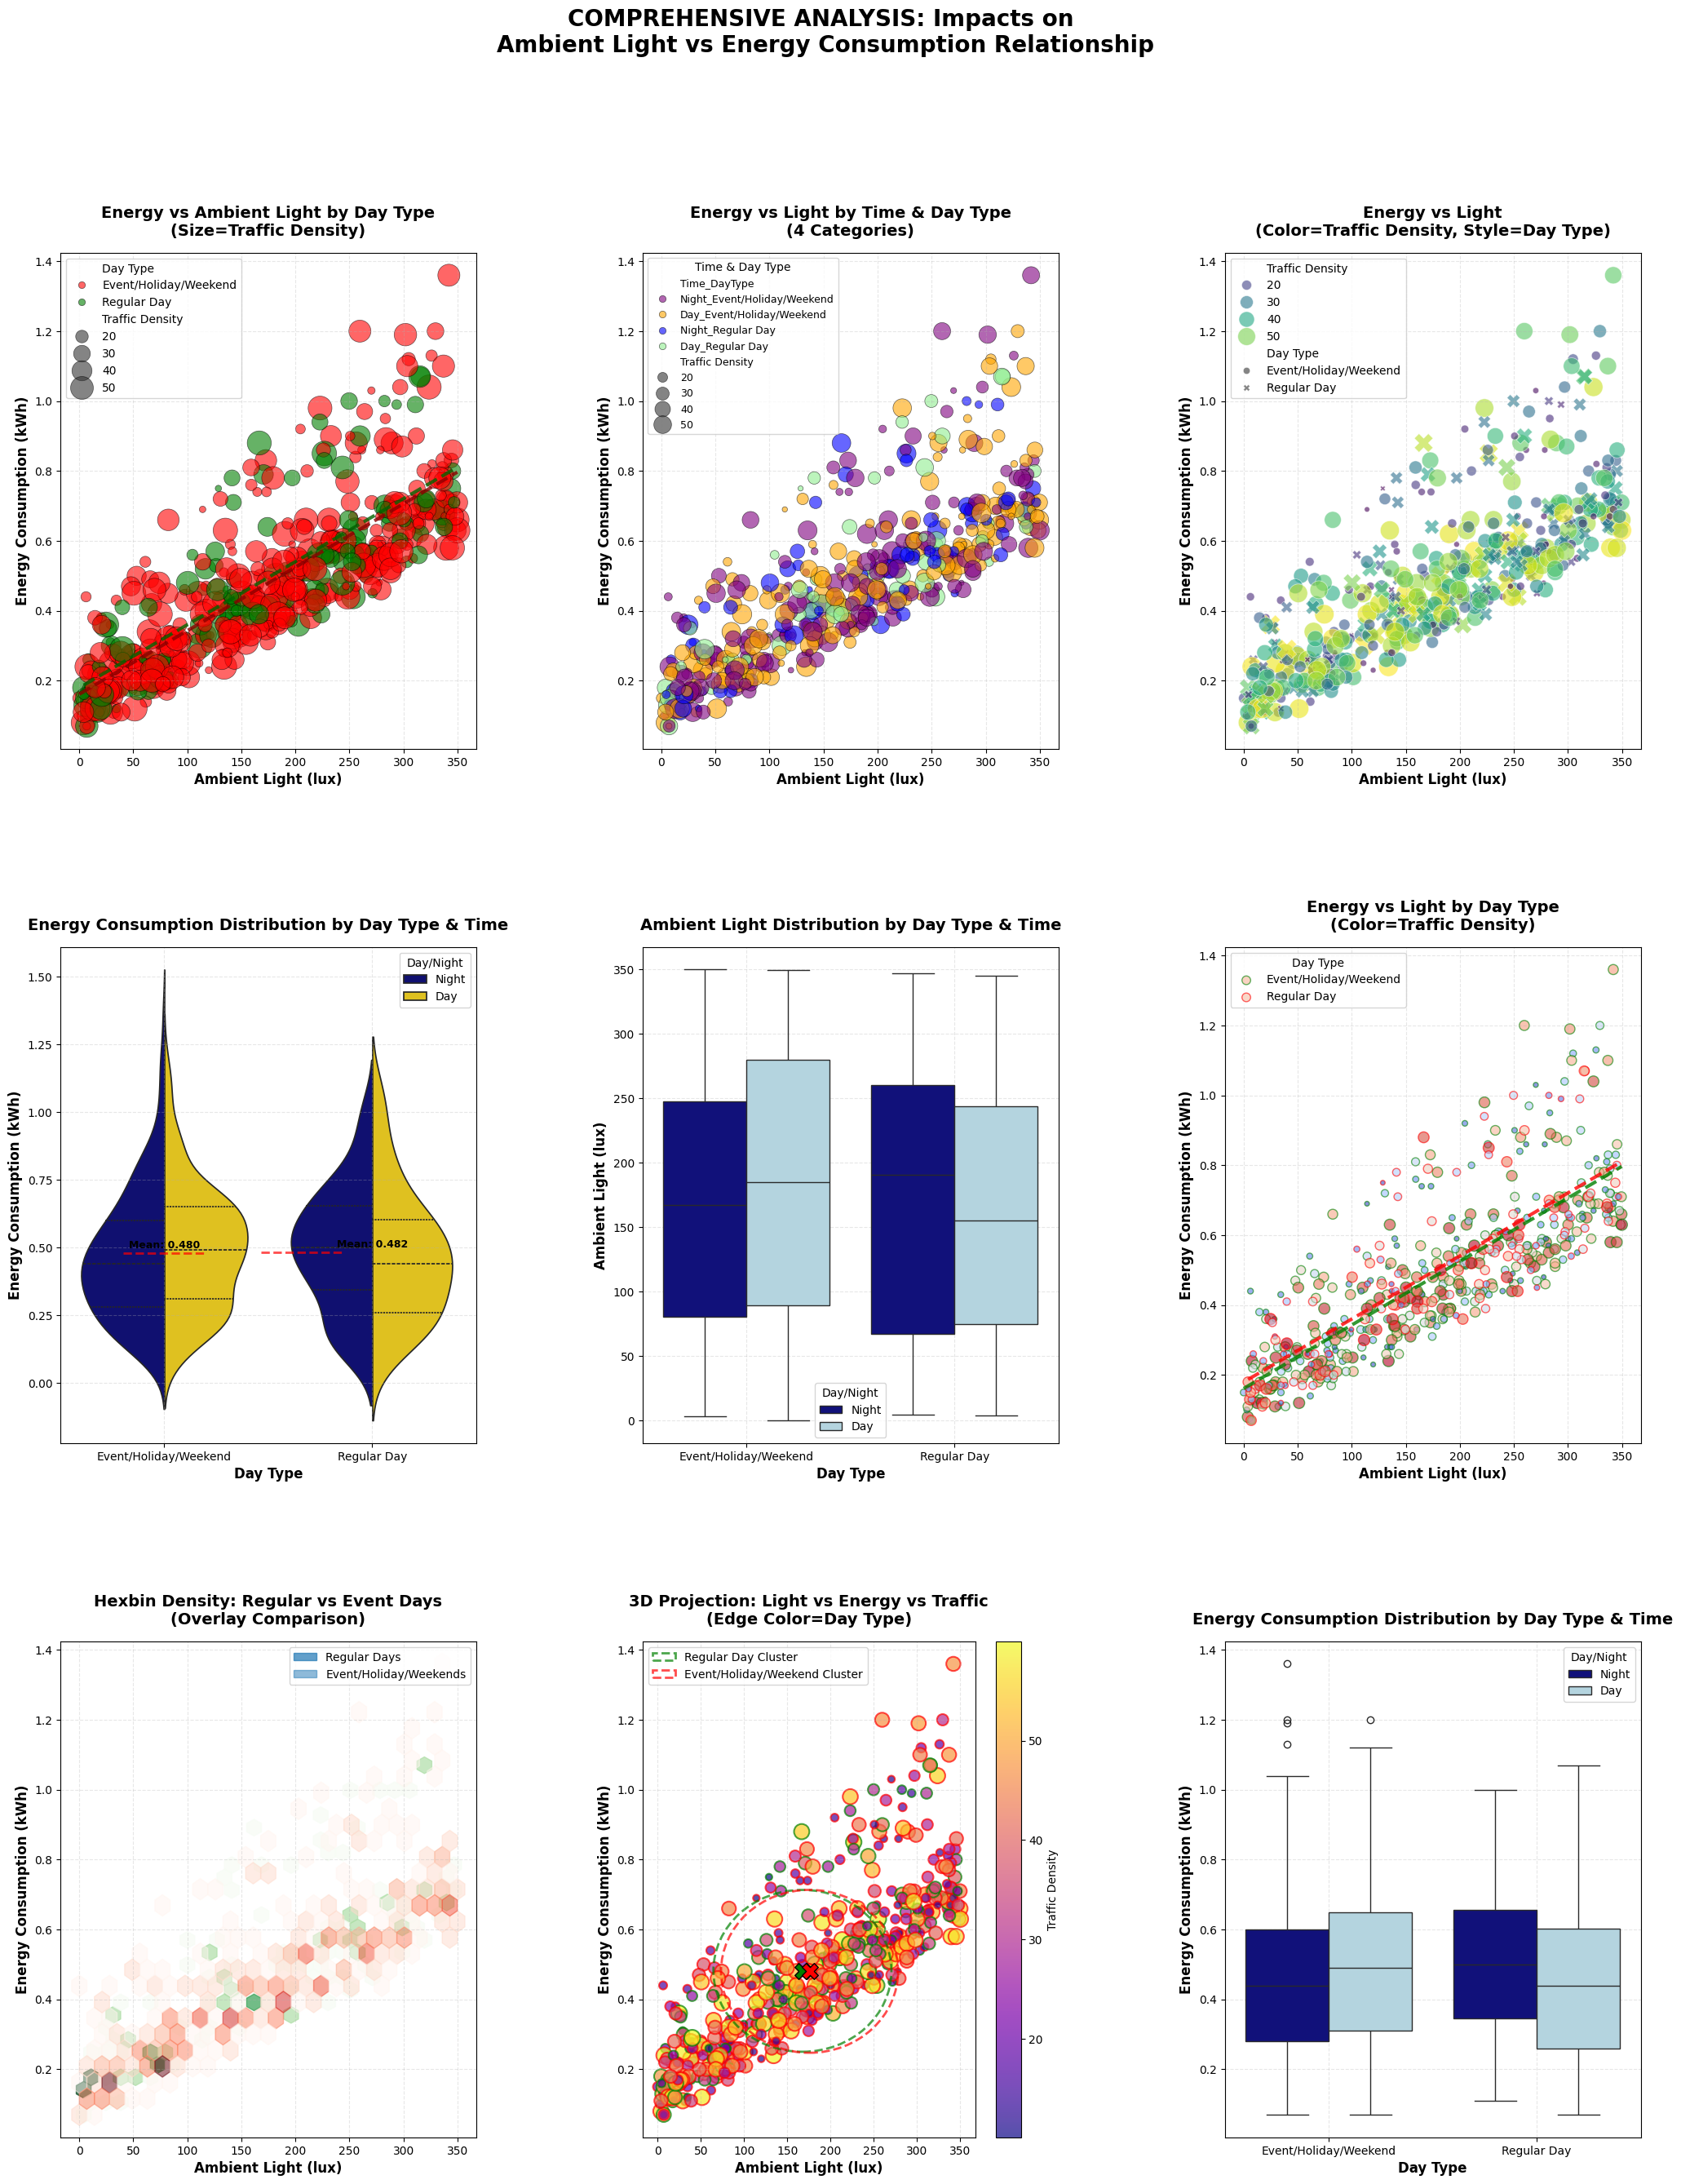

In [171]:
# Create a grid of subplots for different aspects
fig = plt.figure(figsize=(25, 30))  # Increased size for more plots
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.4, wspace=0.4)
non_zero_energy = data[data["Energy Consumption (kWh)"] != 0].copy()

# Add Day Type column if not already present
non_zero_energy["Day Type"] = np.where(
    (non_zero_energy["Special Event"] == 0) & (non_zero_energy["Holiday/Weekend"] == 0),
    "Regular Day",
    "Event/Holiday/Weekend"
)

# Calculate basic statistics by Day Type
day_type_stats = non_zero_energy.groupby("Day Type").agg({
    "Energy Consumption (kWh)": ["mean", "std", "min", "max", "count"],
    "Ambient Light (lux)": ["mean", "std"],
    "Traffic Density": ["mean", "std"]
}).round(3)

print("="*80)
print("DAY TYPE STATISTICS")
print("="*80)
print(day_type_stats)

# 1. MAIN SCATTERPLOT WITH DAY TYPE COLOR (Top-left)
ax1 = fig.add_subplot(gs[0, 0])
scatter1 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Day Type",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Regular Day": "green", "Event/Holiday/Weekend": "red"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax1
)
ax1.set_title("Energy vs Ambient Light by Day Type\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Add regression lines for each Day Type
for day_type, color in [("Regular Day", "darkgreen"), ("Event/Holiday/Weekend", "darkred")]:
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax1.plot(x_range, p(x_range), color=color, linewidth=3, linestyle="--", 
                alpha=0.8, label=f'{day_type} Trend')

# 2. SCATTERPLOT WITH DAY/NIGHT AND DAY TYPE FACET (Top-middle)
ax2 = fig.add_subplot(gs[0, 1])
# Create a combined category for detailed analysis
non_zero_energy["Time_DayType"] = non_zero_energy["Day/Night"] + "_" + non_zero_energy["Day Type"]

scatter2 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Time_DayType",
    size="Traffic Density",
    sizes=(20, 300),
    alpha=0.6,
    palette={"Day_Regular Day": "lightgreen", "Day_Event/Holiday/Weekend": "orange",
             "Night_Regular Day": "blue", "Night_Event/Holiday/Weekend": "purple"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax2
)
ax2.set_title("Energy vs Light by Time & Day Type\n(4 Categories)", 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(title="Time & Day Type", fontsize=9, title_fontsize=10, loc='upper left')

# 3. SCATTERPLOT WITH TRAFFIC DENSITY BY DAY TYPE (Top-right)
ax3 = fig.add_subplot(gs[0, 2])
scatter3 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Traffic Density",
    style="Day Type",
    size="Traffic Density",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.6,
    ax=ax3
)
ax3.set_title("Energy vs Light\n(Color=Traffic Density, Style=Day Type)", 
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. VIOLIN PLOTS COMPARING DAY TYPES (Middle-left)
ax4 = fig.add_subplot(gs[1, 0])
sns.violinplot(
    data=non_zero_energy,
    x="Day Type",
    y="Energy Consumption (kWh)",
    hue="Day/Night",
    split=True,
    palette={"Day": "gold", "Night": "navy"},
    inner="quartile",
    ax=ax4
)
ax4.set_title("Energy Consumption Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax4.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')

# Add mean lines
for i, day_type in enumerate(non_zero_energy["Day Type"].unique()):
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    mean_val = subset["Energy Consumption (kWh)"].mean()
    ax4.axhline(y=mean_val, xmin=i/3 + 0.15, xmax=i/3 + 0.35, 
               color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax4.text(i, mean_val*1.02, f'Mean: {mean_val:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 5. BOX PLOTS OF AMBIENT LIGHT BY DAY TYPE (Middle-middle)
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(
    data=non_zero_energy,
    x="Day Type",
    y="Ambient Light (lux)",
    hue="Day/Night",
    palette={"Day": "lightblue", "Night": "darkblue"},
    ax=ax5
)
ax5.set_title("Ambient Light Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax5.set_ylabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, linestyle='--')
# ax5.set_yscale('log')  # Log scale for better visualization

# 6. SCATTER WITH FACET GRID BY DAY TYPE (Middle-right)
ax6 = fig.add_subplot(gs[1, 2])
# Create a facet-like visualization manually
day_types = non_zero_energy["Day Type"].unique()
colors = ['green', 'red']

for i, day_type in enumerate(day_types):
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    ax6.scatter(
        subset["Ambient Light (lux)"],
        subset["Energy Consumption (kWh)"],
        c=subset["Traffic Density"],
        cmap="coolwarm",
        s=subset["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 100,
        alpha=0.6,
        edgecolors=colors[i],
        linewidth=1,
        label=day_type
    )
    
    # Add regression line for each day type
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax6.plot(x_range, p(x_range), color=colors[i], linewidth=3, linestyle="--", alpha=0.8)

ax6.set_title("Energy vs Light by Day Type\n(Color=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax6.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax6.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.legend(title="Day Type")

# 7. HEXBIN WITH DAY TYPE SEPARATION (Bottom-left)
ax7 = fig.add_subplot(gs[2, 0])
# Create separate hexbin plots
regular_data = non_zero_energy[non_zero_energy["Day Type"] == "Regular Day"]
event_data = non_zero_energy[non_zero_energy["Day Type"] == "Event/Holiday/Weekend"]

# Regular Days hexbin
hex1 = ax7.hexbin(
    regular_data["Ambient Light (lux)"],
    regular_data["Energy Consumption (kWh)"],
    gridsize=25,
    cmap="Greens",
    alpha=0.7,
    mincnt=1,
    label="Regular Days"
)

# Event/Holiday/Weekends hexbin (overlay)
hex2 = ax7.hexbin(
    event_data["Ambient Light (lux)"],
    event_data["Energy Consumption (kWh)"],
    gridsize=25,
    cmap="Reds",
    alpha=0.5,
    mincnt=1,
    label="Event/Holiday/Weekends"
)

ax7.set_title("Hexbin Density: Regular vs Event Days\n(Overlay Comparison)", 
              fontsize=14, fontweight='bold', pad=15)
ax7.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax7.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3, linestyle='--')
ax7.legend()

# 8. 3D SCATTER PROJECTION (Bottom-middle)
ax8 = fig.add_subplot(gs[2, 1])
# Create a 2D scatter with third dimension as color and fourth as size
scatter8 = ax8.scatter(
    non_zero_energy["Ambient Light (lux)"],
    non_zero_energy["Energy Consumption (kWh)"],
    c=non_zero_energy["Traffic Density"],
    cmap="plasma",
    s=non_zero_energy["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 200,
    alpha=0.7,
    edgecolors=non_zero_energy["Day Type"].map({"Regular Day": "green", "Event/Holiday/Weekend": "red"}),
    linewidth=1.5
)

# Add ellipses for each Day Type cluster
for day_type, color in [("Regular Day", "green"), ("Event/Holiday/Weekend", "red")]:
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    if len(subset) > 10:
        mean_x = subset["Ambient Light (lux)"].mean()
        mean_y = subset["Energy Consumption (kWh)"].mean()
        std_x = subset["Ambient Light (lux)"].std()
        std_y = subset["Energy Consumption (kWh)"].std()
        
        ellipse = Ellipse(
            (mean_x, mean_y),
            width=std_x * 2,
            height=std_y * 2,
            angle=0,
            fill=False,
            edgecolor=color,
            linewidth=2,
            linestyle="--",
            alpha=0.7,
            label=f'{day_type} Cluster'
        )
        ax8.add_patch(ellipse)
        
        # Add centroid marker
        ax8.scatter(mean_x, mean_y, color=color, s=200, marker='X', edgecolor='black', linewidth=1)

ax8.set_title("3D Projection: Light vs Energy vs Traffic\n(Edge Color=Day Type)", 
              fontsize=14, fontweight='bold', pad=15)
ax8.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax8.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, linestyle='--')
ax8.legend()
plt.colorbar(scatter8, ax=ax8, label="Traffic Density")

# 9. BOX PLOTS OF AMBIENT LIGHT BY DAY TYPE (Middle-middle)
ax9 = fig.add_subplot(gs[2, 2])
sns.boxplot(
    data=non_zero_energy,
    x="Day Type",
    y="Energy Consumption (kWh)",
    hue="Day/Night",
    palette={"Day": "lightblue", "Night": "darkblue"},
    ax=ax9
)
ax9.set_title("Energy Consumption Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax9.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax9.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3, linestyle='--')

# Calculate detailed statistics
regular_stats = non_zero_energy[non_zero_energy["Day Type"] == "Regular Day"]
event_stats = non_zero_energy[non_zero_energy["Day Type"] == "Event/Holiday/Weekend"]

# Perform statistical tests
if len(regular_stats) > 0 and len(event_stats) > 0:
    # T-test for energy consumption
    t_stat_energy, p_val_energy = stats.ttest_ind(
        regular_stats["Energy Consumption (kWh)"],
        event_stats["Energy Consumption (kWh)"],
        equal_var=False
    )
    
    # T-test for ambient light
    t_stat_light, p_val_light = stats.ttest_ind(
        regular_stats["Ambient Light (lux)"],
        event_stats["Ambient Light (lux)"],
        equal_var=False
    )
    
    # T-test for traffic density
    t_stat_traffic, p_val_traffic = stats.ttest_ind(
        regular_stats["Traffic Density"],
        event_stats["Traffic Density"],
        equal_var=False
    )

print(f"""
DETAILED DAY TYPE ANALYSIS - STATISTICAL COMPARISON
{'='*80}

SAMPLE COUNTS:
• Regular Days: {len(regular_stats):,} samples ({len(regular_stats)/len(non_zero_energy)*100:.1f}%)
• Event/Holiday/Weekends: {len(event_stats):,} samples ({len(event_stats)/len(non_zero_energy)*100:.1f}%)

ENERGY CONSUMPTION (kWh):
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Energy Consumption (kWh)'].mean():10.3f}   {event_stats['Energy Consumption (kWh)'].mean():10.3f}               {event_stats['Energy Consumption (kWh)'].mean() - regular_stats['Energy Consumption (kWh)'].mean():10.3f} {(event_stats['Energy Consumption (kWh)'].mean() - regular_stats['Energy Consumption (kWh)'].mean())/regular_stats['Energy Consumption (kWh)'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Energy Consumption (kWh)'].std():10.3f}   {event_stats['Energy Consumption (kWh)'].std():10.3f}
Min:            {regular_stats['Energy Consumption (kWh)'].min():10.3f}   {event_stats['Energy Consumption (kWh)'].min():10.3f}
Max:            {regular_stats['Energy Consumption (kWh)'].max():10.3f}   {event_stats['Energy Consumption (kWh)'].max():10.3f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_energy:7.4f}

AMBIENT LIGHT (lux):
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Ambient Light (lux)'].mean():10.1f}   {event_stats['Ambient Light (lux)'].mean():10.1f}               {event_stats['Ambient Light (lux)'].mean() - regular_stats['Ambient Light (lux)'].mean():10.1f} {(event_stats['Ambient Light (lux)'].mean() - regular_stats['Ambient Light (lux)'].mean())/regular_stats['Ambient Light (lux)'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Ambient Light (lux)'].std():10.1f}   {event_stats['Ambient Light (lux)'].std():10.1f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_light:7.4f}

TRAFFIC DENSITY:
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Traffic Density'].mean():10.1f}   {event_stats['Traffic Density'].mean():10.1f}               {event_stats['Traffic Density'].mean() - regular_stats['Traffic Density'].mean():10.1f} {(event_stats['Traffic Density'].mean() - regular_stats['Traffic Density'].mean())/regular_stats['Traffic Density'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Traffic Density'].std():10.1f}   {event_stats['Traffic Density'].std():10.1f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_traffic:7.4f}

CORRELATION ANALYSIS:
{'─'*40}
                       Regular Days    Event/Holidays   Difference
Light-Energy:         {regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)']) - regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}
Traffic-Energy:       {regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)']) - regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}
Light-Traffic:        {regular_stats['Ambient Light (lux)'].corr(regular_stats['Traffic Density']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Traffic Density']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Traffic Density']) - regular_stats['Ambient Light (lux)'].corr(regular_stats['Traffic Density']):12.3f}

KEY INSIGHTS:
{'─'*40}
1. Energy Consumption: {'Higher on Event Days' if event_stats['Energy Consumption (kWh)'].mean() > regular_stats['Energy Consumption (kWh)'].mean() else 'Higher on Regular Days'}
2. Light Sensitivity: {'Stronger correlation on Event Days' if abs(event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)'])) > abs(regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)'])) else 'Stronger correlation on Regular Days'}
3. Traffic Impact: {'More influential on Event Days' if abs(event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)'])) > abs(regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)'])) else 'More influential on Regular Days'}
4. Statistical Significance (p < 0.05):
   • Energy: {'SIGNIFICANT' if p_val_energy < 0.05 else 'NOT SIGNIFICANT'}
   • Light: {'SIGNIFICANT' if p_val_light < 0.05 else 'NOT SIGNIFICANT'}
   • Traffic: {'SIGNIFICANT' if p_val_traffic < 0.05 else 'NOT SIGNIFICANT'}
""")

plt.suptitle("COMPREHENSIVE ANALYSIS: Impacts on \nAmbient Light vs Energy Consumption Relationship", 
             fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()




STATISTICAL ANALYSIS OF AMBIENT LIGHT VS ENERGY CONSUMPTION

Overall Statistics:
• Total Samples: 503
• Ambient Light Range: 0.1 - 349.7 lux
• Energy Consumption Range: 0.07 - 1.36 kWh
• Traffic Density Range: 10.1 - 60.0

Correlation Analysis:
• Light-Energy Correlation: 0.798
• Traffic-Energy Correlation: -0.047
• Light-Traffic Correlation: -0.007

Average Energy Consumption:
• Daytime Average: 0.488 kWh
• Nighttime Average: 0.474 kWh
• Difference: -0.015 kWh

Traffic Impact:
• High Traffic (Top 25%): Avg Energy = 0.449 kWh
• Low Traffic (Bottom 25%): Avg Energy = 0.476 kWh



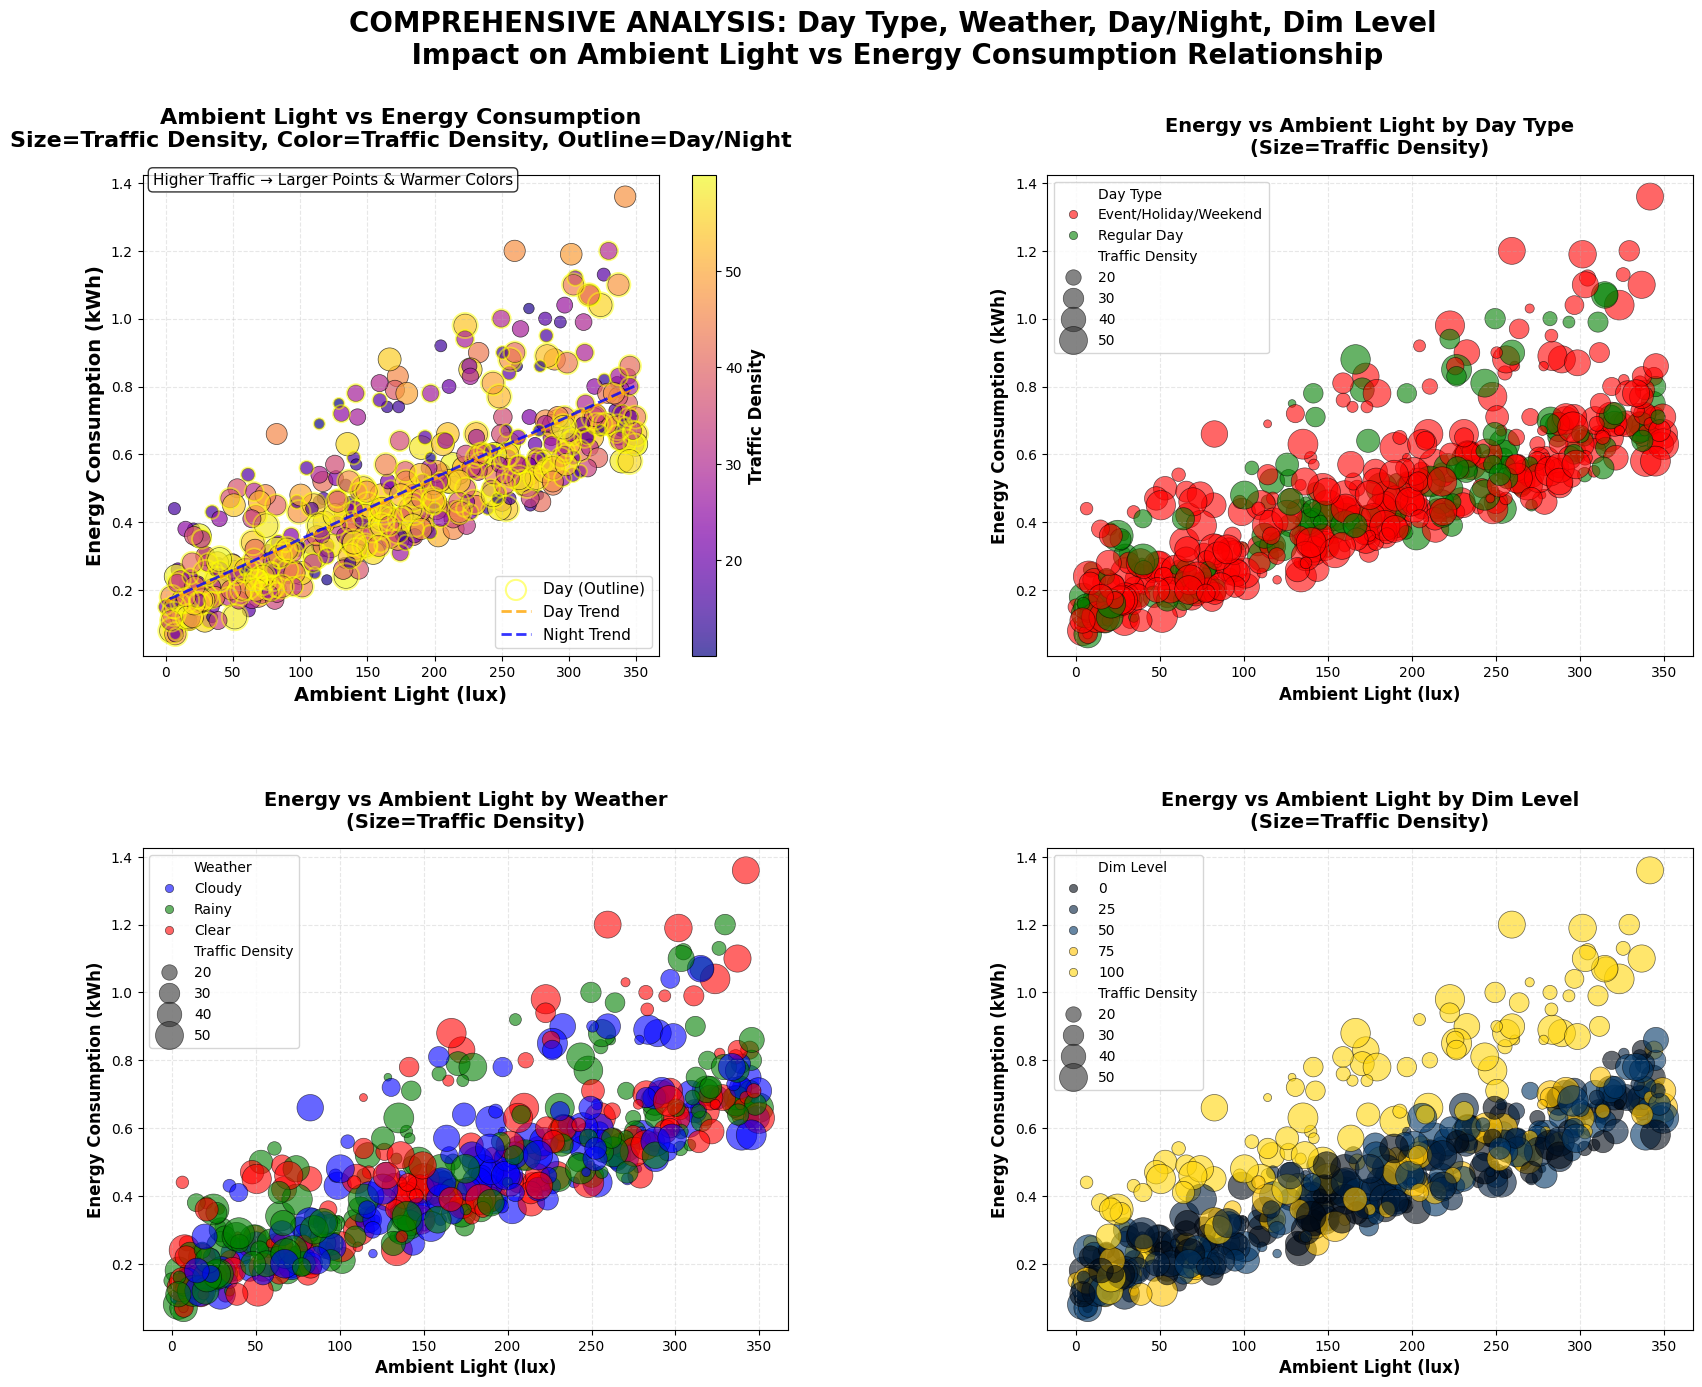

In [172]:
# Calculate statistics
print(f"""
STATISTICAL ANALYSIS OF AMBIENT LIGHT VS ENERGY CONSUMPTION

Overall Statistics:
• Total Samples: {len(non_zero_energy):,}
• Ambient Light Range: {non_zero_energy['Ambient Light (lux)'].min():.1f} - {non_zero_energy['Ambient Light (lux)'].max():.1f} lux
• Energy Consumption Range: {non_zero_energy['Energy Consumption (kWh)'].min():.2f} - {non_zero_energy['Energy Consumption (kWh)'].max():.2f} kWh
• Traffic Density Range: {non_zero_energy['Traffic Density'].min():.1f} - {non_zero_energy['Traffic Density'].max():.1f}

Correlation Analysis:
• Light-Energy Correlation: {non_zero_energy['Ambient Light (lux)'].corr(non_zero_energy['Energy Consumption (kWh)']):.3f}
• Traffic-Energy Correlation: {non_zero_energy['Traffic Density'].corr(non_zero_energy['Energy Consumption (kWh)']):.3f}
• Light-Traffic Correlation: {non_zero_energy['Ambient Light (lux)'].corr(non_zero_energy['Traffic Density']):.3f}

Average Energy Consumption:
• Daytime Average: {non_zero_energy[non_zero_energy['Day/Night'] == 'Day']['Energy Consumption (kWh)'].mean():.3f} kWh
• Nighttime Average: {non_zero_energy[non_zero_energy['Day/Night'] == 'Night']['Energy Consumption (kWh)'].mean():.3f} kWh
• Difference: {(non_zero_energy[non_zero_energy['Day/Night'] == 'Night']['Energy Consumption (kWh)'].mean() - non_zero_energy[non_zero_energy['Day/Night'] == 'Day']['Energy Consumption (kWh)'].mean()):.3f} kWh

Traffic Impact:
• High Traffic (Top 25%): Avg Energy = {non_zero_energy[non_zero_energy['Traffic Density'] > non_zero_energy['Traffic Density'].quantile(0.75)]['Energy Consumption (kWh)'].mean():.3f} kWh
• Low Traffic (Bottom 25%): Avg Energy = {non_zero_energy[non_zero_energy['Traffic Density'] < non_zero_energy['Traffic Density'].quantile(0.25)]['Energy Consumption (kWh)'].mean():.3f} kWh
""")

fig = plt.figure(figsize=(20,15))  # Increased size for more plots
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.4)

# Create scatterplot with multiple encodings
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(
    non_zero_energy["Ambient Light (lux)"],
    non_zero_energy["Energy Consumption (kWh)"],
    c=non_zero_energy["Traffic Density"],
    cmap="plasma",
    s=non_zero_energy["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 300,  # Dynamic sizing
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

# Add Day/Night encoding with different markers
day_mask = non_zero_energy["Day/Night"] == "Day"
ax1.scatter(
    non_zero_energy.loc[day_mask, "Ambient Light (lux)"],
    non_zero_energy.loc[day_mask, "Energy Consumption (kWh)"],
    facecolors='none',
    edgecolors='yellow',
    s=non_zero_energy.loc[day_mask, "Traffic Density"]/non_zero_energy["Traffic Density"].max() * 300 * 1.2,
    linewidth=1.5,
    alpha=0.5,
    label='Day (Outline)'
)

# Add regression lines for Day and Night
for day_night, color in [("Day", "orange"), ("Night", "blue")]:
    subset = non_zero_energy[non_zero_energy["Day/Night"] == day_night]
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax1.plot(x_range, p(x_range), color=color, linewidth=2, linestyle="--", 
                label=f'{day_night} Trend', alpha=0.8)

ax1.set_title("Ambient Light vs Energy Consumption\nSize=Traffic Density, Color=Traffic Density, Outline=Day/Night", 
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Ambient Light (lux)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Energy Consumption (kWh)", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', fontsize=11)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Traffic Density', fontsize=12, fontweight='bold')

# Add annotations for key insights
ax1.annotate('Higher Traffic → Larger Points & Warmer Colors', 
            xy=(0.02, 0.98), xycoords='axes fraction',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2 = fig.add_subplot(gs[0, 1])
scatter2 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Day Type",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Regular Day": "green", "Event/Holiday/Weekend": "red"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax2
)
ax2.set_title("Energy vs Ambient Light by Day Type\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

ax3 = fig.add_subplot(gs[1, 0])
scatter3 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Weather",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Clear": "red", "Rainy": "green", "Cloudy":"blue"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax3
)
ax3.set_title("Energy vs Ambient Light by Weather\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

ax4 = fig.add_subplot(gs[1, 1])
scatter4 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Dim Level",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={0:"#000814", 25:"#001d3d",50: "#003566", 75: "#ffc300", 100: "#ffd60a"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax4
)
ax4.set_title("Energy vs Ambient Light by Dim Level\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax4.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')

plt.suptitle("COMPREHENSIVE ANALYSIS: Day Type, Weather, Day/Night, Dim Level\n Impact on Ambient Light vs Energy Consumption Relationship", 
             fontsize=20, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()

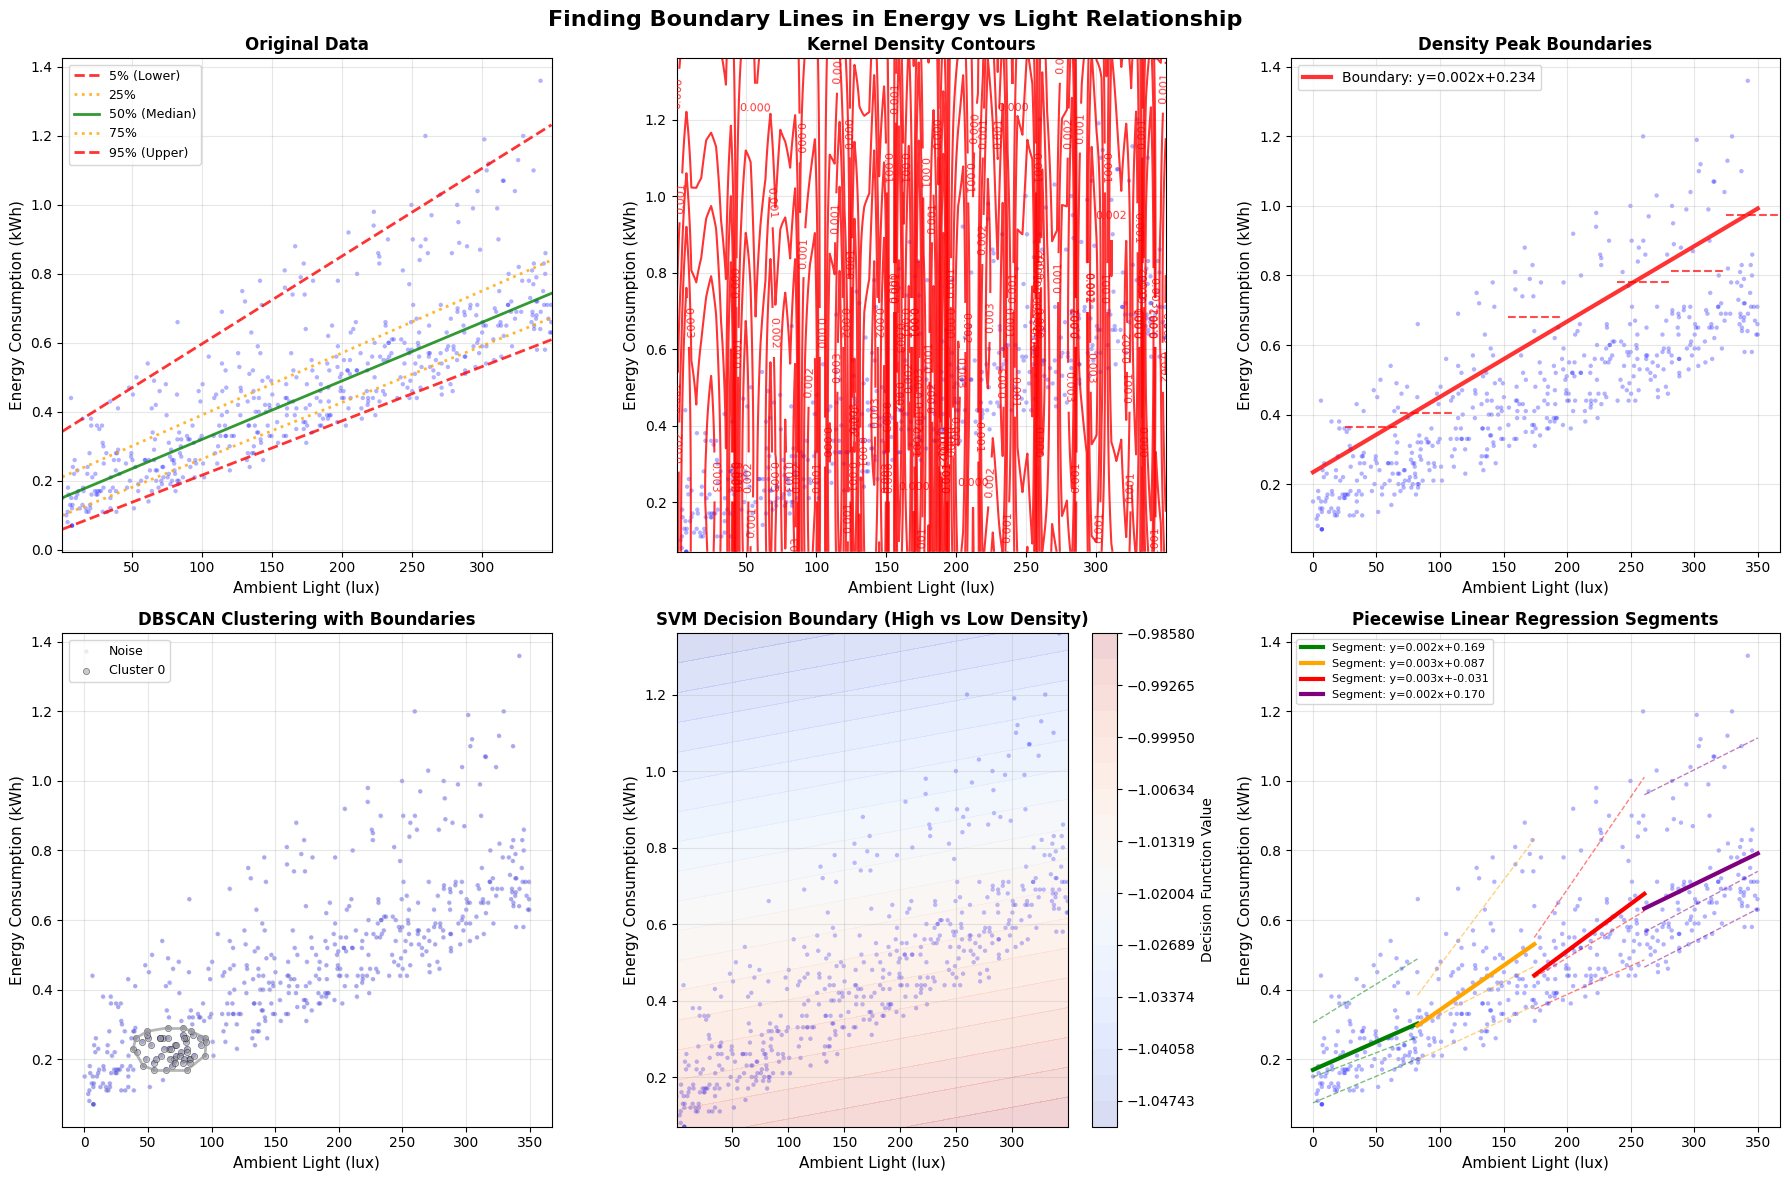


BOUNDARY EQUATIONS:
Upper Bound (Out-of-ordinary max): y = -4.29e-06x² + 0.004x + 0.272
Separation Line: y = 8.93e-07x² + 0.002x + 0.262
Lower Bound (Ordinary min): y = -1.69e-07x² + 0.002x + 0.094


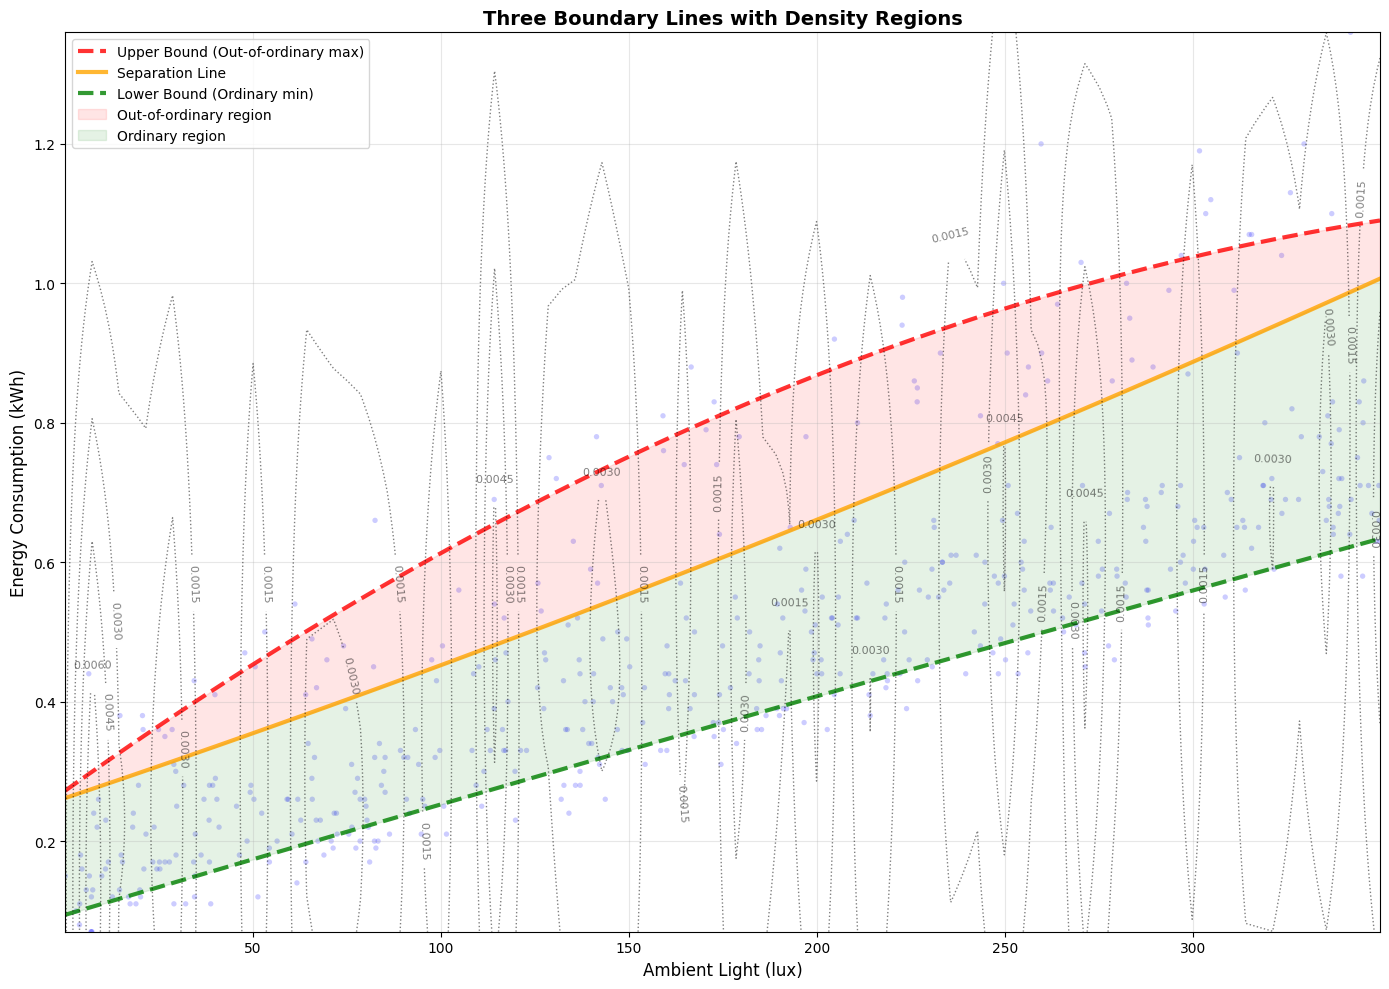


POINT CLASSIFICATION BASED ON BOUNDARIES

Classification Summary:
  Ordinary: 328 points (65.2%)
  Below Lower Bound (Extreme Low): 92 points (18.3%)
  Out-of-ordinary: 51 points (10.1%)
  Above Upper Bound (Extreme Outlier): 32 points (6.4%)


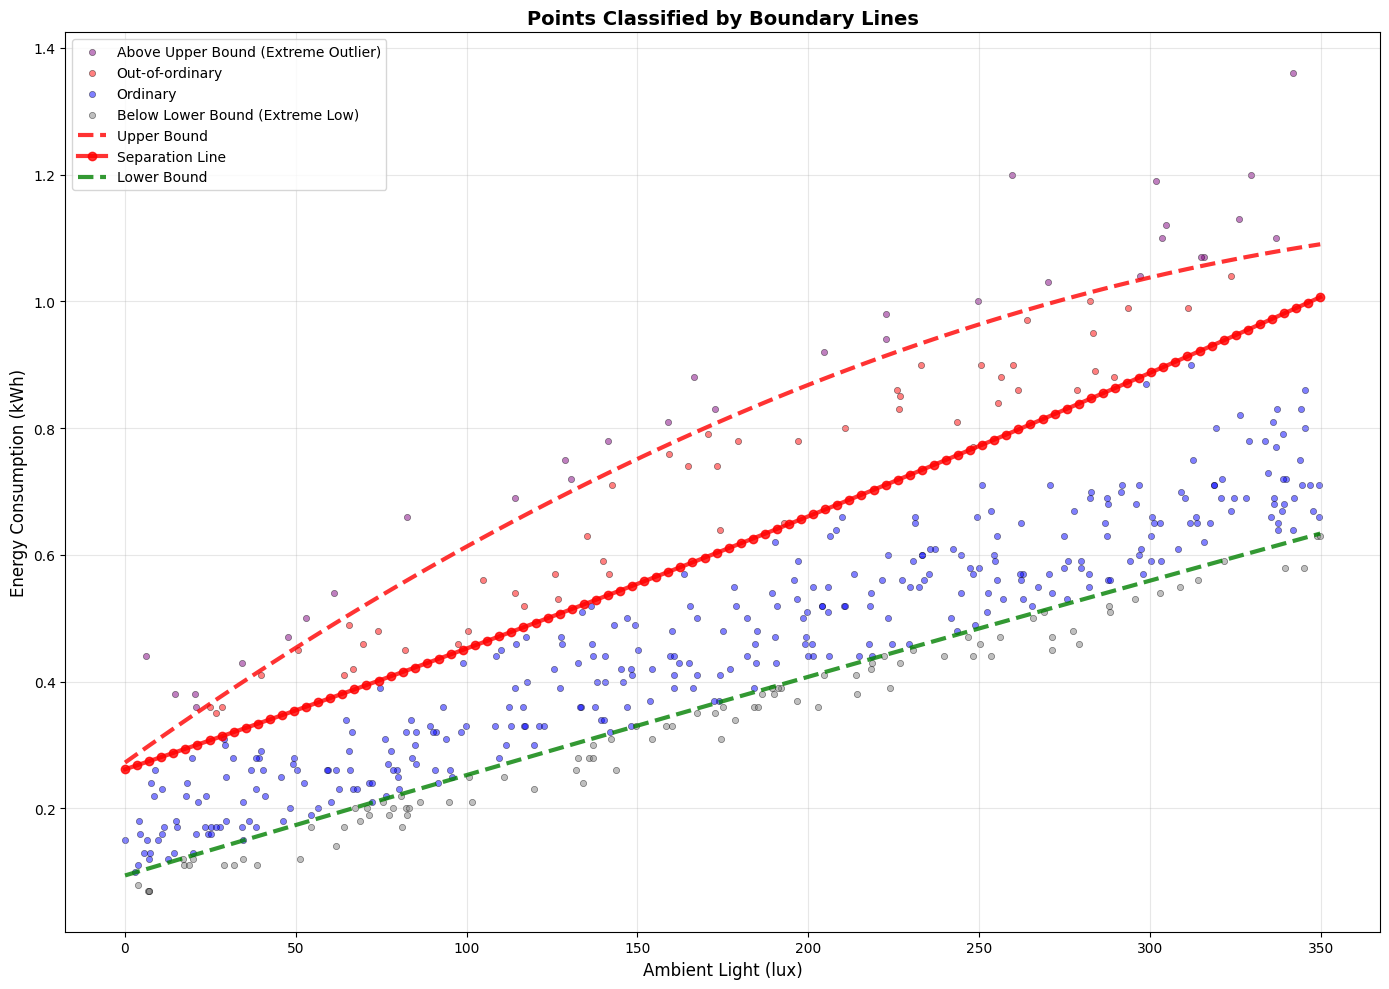

In [173]:
from sklearn.linear_model import QuantileRegressor
from sklearn.neighbors import KernelDensity

# 1. Prepare data
non_zero_energy = data[data["Energy Consumption (kWh)"] != 0].copy()
X = non_zero_energy["Ambient Light (lux)"].values.reshape(-1, 1)
y = non_zero_energy["Energy Consumption (kWh)"].values

# Quantile Regression for boundaries
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Finding Boundary Lines in Energy vs Light Relationship', fontsize=16, fontweight='bold')

# Plot 1: Original scatter
ax1 = axes[0, 0]
scatter = ax1.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')
ax1.set_title('Original Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Ambient Light (lux)', fontsize=11)
ax1.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax1.grid(True, alpha=0.3)

# Fit quantile regressions for different percentiles
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
colors = ['red', 'orange', 'green', 'orange', 'red']
line_styles = ['--', ':', '-', ':', '--']
labels = ['5% (Lower)', '25%', '50% (Median)', '75%', '95% (Upper)']

for q, color, ls, label in zip(quantiles, colors, line_styles, labels):
    qr = QuantileRegressor(quantile=q, alpha=0)
    qr.fit(X, y)
    y_pred = qr.predict(X)
    
    # Sort for plotting
    sort_idx = np.argsort(X.flatten())
    ax1.plot(X[sort_idx], y_pred[sort_idx], color=color, linestyle=ls, 
             linewidth=2, label=f'{label}', alpha=0.8)

ax1.legend(fontsize=9)
ax1.set_xlim([X.min(), X.max()])

ax2 = axes[0, 1]
ax2.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Create grid for KDE
x_grid = np.linspace(X.min(), X.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Flatten for KDE
positions = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
values = np.vstack([X.flatten(), y]).T

# Fit KDE
kde = KernelDensity(bandwidth=0.5, kernel='gaussian')
kde.fit(values)

# Calculate density on grid
Z = np.exp(kde.score_samples(positions))
Z = Z.reshape(X_grid.shape)

# Plot density contours
levels = np.percentile(Z, [10, 30, 50, 70, 90])
contour = ax2.contour(X_grid, Y_grid, Z, levels=levels, colors='red', 
                      linewidths=1.5, alpha=0.8)
ax2.clabel(contour, inline=True, fontsize=8, fmt='%.3f')

ax2.set_title('Kernel Density Contours', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ambient Light (lux)', fontsize=11)
ax2.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax2.grid(True, alpha=0.3)

# Find density peaks and boundaries
ax3 = axes[0, 2]
ax3.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Find local maxima in density
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# Project density onto y-axis for different x ranges
x_bins = np.linspace(X.min(), X.max(), 10)
boundary_points = []

for i in range(len(x_bins)-1):
    mask = (X.flatten() >= x_bins[i]) & (X.flatten() < x_bins[i+1])
    if mask.sum() > 10:
        y_slice = y[mask]
        
        # Create histogram of y values
        hist, bin_edges = np.histogram(y_slice, bins=30)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Smooth histogram
        smoothed_hist = gaussian_filter1d(hist.astype(float), sigma=2)
        
        # Find peaks
        peaks, properties = find_peaks(smoothed_hist, height=np.percentile(smoothed_hist, 50))
        
        if len(peaks) >= 2:
            # Get valley between two highest peaks
            peak_heights = smoothed_hist[peaks]
            top_peaks = peaks[np.argsort(peak_heights)[-2:]]
            valley_idx = np.argmin(smoothed_hist[min(top_peaks):max(top_peaks)]) + min(top_peaks)
            boundary_y = bin_centers[valley_idx]
            boundary_x = (x_bins[i] + x_bins[i+1]) / 2
            boundary_points.append([boundary_x, boundary_y])
            
            ax3.axhline(y=boundary_y, xmin=x_bins[i]/(X.max()-X.min()), 
                       xmax=x_bins[i+1]/(X.max()-X.min()), 
                       color='red', linestyle='--', alpha=0.7)

# Fit line through boundary points
if len(boundary_points) > 2:
    boundary_points = np.array(boundary_points)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        boundary_points[:, 0], boundary_points[:, 1]
    )
    
    x_line = np.array([X.min(), X.max()])
    y_line = slope * x_line + intercept
    ax3.plot(x_line, y_line, 'r-', linewidth=3, alpha=0.8, 
             label=f'Boundary: y={slope:.3f}x+{intercept:.3f}')

ax3.set_title('Density Peak Boundaries', fontsize=12, fontweight='bold')
ax3.set_xlabel('Ambient Light (lux)', fontsize=11)
ax3.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax3.legend()
ax3.grid(True, alpha=0.3)

# DBSCAN for cluster separation
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull

ax4 = axes[1, 0]
ax4.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Scale data for DBSCAN
from sklearn.preprocessing import StandardScaler
data_scaled = StandardScaler().fit_transform(np.column_stack([X.flatten(), y]))

# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=50)
clusters = dbscan.fit_predict(data_scaled)

# Plot clusters
unique_clusters = np.unique(clusters)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_clusters)))

for cluster, color in zip(unique_clusters, colors):
    if cluster == -1:  # Noise
        mask = clusters == cluster
        ax4.scatter(X[mask], y[mask], alpha=0.1, s=5, c='gray', label='Noise')
    else:
        mask = clusters == cluster
        ax4.scatter(X[mask], y[mask], alpha=0.5, s=20, c=color, 
                   edgecolors='black', linewidth=0.5, label=f'Cluster {cluster}')
        
        # Find convex hull for cluster boundary
        if mask.sum() > 3:
            points = np.column_stack([X[mask].flatten(), y[mask]])
            try:
                hull = ConvexHull(points)
                for simplex in hull.simplices:
                    ax4.plot(points[simplex, 0], points[simplex, 1], 
                            color=color, linewidth=2, alpha=0.7)
            except:
                pass

ax4.set_title('DBSCAN Clustering with Boundaries', fontsize=12, fontweight='bold')
ax4.set_xlabel('Ambient Light (lux)', fontsize=11)
ax4.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax4.legend(fontsize=9, loc='upper left')
ax4.grid(True, alpha=0.3)

#Support Vector Machine (SVM) for optimal separation
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Fixed SVM Plot Section
ax5 = axes[1, 1]
ax5.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Create binary labels based on density (high vs low density regions)
kde_2d = KernelDensity(bandwidth=0.3)
kde_2d.fit(np.column_stack([X.flatten(), y]))
log_densities = kde_2d.score_samples(np.column_stack([X.flatten(), y]))

# Label points: 1 for high density, 0 for low density
density_threshold = np.percentile(log_densities, 70)
labels = (log_densities > density_threshold).astype(int)

# Train SVM
X_train, X_test, y_train, y_test = train_test_split(
    np.column_stack([X.flatten(), y]), labels, test_size=0.3, random_state=42
)

svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)

# Create mesh for decision boundary
x_min, x_max = X.min(), X.max()
y_min, y_max = y.min(), y.max()
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# FIX: Create properly ordered levels for contourf
levels = np.linspace(Z.min(), Z.max(), 20)  # Create multiple levels
levels = np.sort(levels)  # Ensure they're sorted

# Plot decision boundary (contour at 0)
ax5.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red', linestyles='--')

# Plot filled contours with properly ordered levels
contourf_plot = ax5.contourf(xx, yy, Z, levels=levels, alpha=0.2, cmap='coolwarm')

ax5.set_title('SVM Decision Boundary (High vs Low Density)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Ambient Light (lux)', fontsize=11)
ax5.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax5.grid(True, alpha=0.3)

# Add colorbar
plt.colorbar(contourf_plot, ax=ax5, label='Decision Function Value')

# Piecewise Linear Regression for 3 boundaries
ax6 = axes[1, 2]
ax6.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Sort data
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx].flatten()
y_sorted = y[sort_idx]

# Use quantiles to define segments
x_quantiles = np.percentile(X_sorted, [25, 50, 75])

# Fit separate linear regressions for each segment
segments = [(X_sorted.min(), x_quantiles[0]),
            (x_quantiles[0], x_quantiles[1]),
            (x_quantiles[1], x_quantiles[2]),
            (x_quantiles[2], X_sorted.max())]

colors_seg = ['green', 'orange', 'red', 'purple']

for (x_start, x_end), color in zip(segments, colors_seg):
    mask = (X_sorted >= x_start) & (X_sorted <= x_end)
    if mask.sum() > 2:
        x_seg = X_sorted[mask]
        y_seg = y_sorted[mask]
        
        # Fit linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_seg, y_seg)
        
        # Plot segment
        x_plot = np.array([x_start, x_end])
        y_plot = slope * x_plot + intercept
        ax6.plot(x_plot, y_plot, color=color, linewidth=3, linestyle='-',
                label=f'Segment: y={slope:.3f}x+{intercept:.3f}')
        
        # Also plot quantile boundaries
        for q in [0.1, 0.5, 0.9]:
            qr = QuantileRegressor(quantile=q, alpha=0)
            qr.fit(x_seg.reshape(-1, 1), y_seg)
            y_q = qr.predict(x_plot.reshape(-1, 1))
            ax6.plot(x_plot, y_q, color=color, linewidth=1, linestyle='--', alpha=0.5)

ax6.set_title('Piecewise Linear Regression Segments', fontsize=12, fontweight='bold')
ax6.set_xlabel('Ambient Light (lux)', fontsize=11)
ax6.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# COMPREHENSIVE BOUNDARY DETECTION
fig, ax = plt.subplots(figsize=(14, 10))

# Plot original data with transparency
scatter = ax.scatter(X, y, alpha=0.2, s=15, c='blue', edgecolors='none')

# Upper bound (95th percentile moving window)
window_size = 100
x_sorted = np.sort(X.flatten())
upper_bound = []
lower_bound = []
middle_bound = []

for i in range(0, len(x_sorted), window_size//10):
    window_end = min(i + window_size, len(x_sorted))
    x_window = x_sorted[i:window_end]
    
    if len(x_window) > 10:
        # Find corresponding y values
        mask = (X.flatten() >= x_window[0]) & (X.flatten() <= x_window[-1])
        y_window = y[mask]
        
        if len(y_window) > 5:
            # Upper bound (95th percentile)
            upper_y = np.percentile(y_window, 95)
            upper_x = np.median(x_window)
            upper_bound.append([upper_x, upper_y])
            
            # Lower bound (5th percentile)
            lower_y = np.percentile(y_window, 5)
            lower_x = np.percentile(x_window, 5)
            lower_bound.append([lower_x, lower_y])
            
            # Middle boundary (based on density valley)
            hist, bin_edges = np.histogram(y_window, bins=30)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Find major peaks
            from scipy.signal import find_peaks
            smoothed_hist = gaussian_filter1d(hist.astype(float), sigma=2)
            peaks, properties = find_peaks(smoothed_hist, 
                                          height=np.percentile(smoothed_hist, 50),
                                          distance=5)
            
            if len(peaks) >= 2:
                # Find valley between two highest peaks
                peak_heights = smoothed_hist[peaks]
                top_peaks = peaks[np.argsort(peak_heights)[-2:]]
                if max(top_peaks) - min(top_peaks) > 3:
                    valley_slice = smoothed_hist[min(top_peaks):max(top_peaks)]
                    valley_idx = np.argmin(valley_slice) + min(top_peaks)
                    middle_y = bin_centers[valley_idx]
                    middle_bound.append([upper_x, middle_y])

# Convert to arrays
upper_bound = np.array(upper_bound)
lower_bound = np.array(lower_bound)
middle_bound = np.array(middle_bound)

# Fit lines through boundary points
def fit_boundary_line(points, label, color, linestyle='-'):
    if len(points) > 2:
        # Fit polynomial (allow curvature)
        coeffs = np.polyfit(points[:, 0], points[:, 1], 2)
        poly = np.poly1d(coeffs)
        
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = poly(x_line)
        
        ax.plot(x_line, y_line, color=color, linewidth=3, 
                linestyle=linestyle, label=label, alpha=0.8)
        
        # Calculate equation
        equation = f"y = {coeffs[0]:.2e}x² + {coeffs[1]:.3f}x + {coeffs[2]:.3f}"
        print(f"{label}: {equation}")
        
        return poly
    return None

# Fit and plot all three boundaries
print("\nBOUNDARY EQUATIONS:")
upper_poly = fit_boundary_line(upper_bound, "Upper Bound (Out-of-ordinary max)", "red", "--")
middle_poly = fit_boundary_line(middle_bound, "Separation Line", "orange", "-")
lower_poly = fit_boundary_line(lower_bound, "Lower Bound (Ordinary min)", "green", "--")

# Add shaded regions
if upper_poly is not None and middle_poly is not None:
    x_fill = np.linspace(X.min(), X.max(), 100)
    ax.fill_between(x_fill, middle_poly(x_fill), upper_poly(x_fill), 
                   color='red', alpha=0.1, label='Out-of-ordinary region')

if middle_poly is not None and lower_poly is not None:
    ax.fill_between(x_fill, lower_poly(x_fill), middle_poly(x_fill), 
                   color='green', alpha=0.1, label='Ordinary region')

# Add density contour for reference
x_grid = np.linspace(X.min(), X.max(), 50)
y_grid = np.linspace(y.min(), y.max(), 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
kde = KernelDensity(bandwidth=0.5)
kde.fit(np.column_stack([X.flatten(), y]))
Z = np.exp(kde.score_samples(positions))
Z = Z.reshape(X_grid.shape)

contour = ax.contour(X_grid, Y_grid, Z, levels=5, colors='black', 
                    linewidths=1, alpha=0.5, linestyles=':')
ax.clabel(contour, inline=True, fontsize=8)

# Finalize plot
ax.set_title('Three Boundary Lines with Density Regions', fontsize=14, fontweight='bold')
ax.set_xlabel('Ambient Light (lux)', fontsize=12)
ax.set_ylabel('Energy Consumption (kWh)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CLASSIFY POINTS BASED ON BOUNDARIES
print("\n" + "="*80)
print("POINT CLASSIFICATION BASED ON BOUNDARIES")
print("="*80)

if upper_poly is not None and middle_poly is not None and lower_poly is not None:
    # Classify each point
    classifications = []
    for x_val, y_val in zip(X.flatten(), y):
        upper_y = upper_poly(x_val)
        middle_y = middle_poly(x_val)
        lower_y = lower_poly(x_val)
        
        if y_val > upper_y:
            classification = "Above Upper Bound (Extreme Outlier)"
        elif y_val > middle_y:
            classification = "Out-of-ordinary"
        elif y_val > lower_y:
            classification = "Ordinary"
        else:
            classification = "Below Lower Bound (Extreme Low)"
        
        classifications.append(classification)
    
    # Add classification to data
    non_zero_energy['Boundary_Classification'] = classifications
    
    # Print summary
    print("\nClassification Summary:")
    class_counts = pd.Series(classifications).value_counts()
    for class_name, count in class_counts.items():
        percentage = count / len(classifications) * 100
        print(f"  {class_name}: {count:,} points ({percentage:.1f}%)")
    
    # Plot classified points
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Color map for classifications
    color_map = {
        "Above Upper Bound (Extreme Outlier)": "purple",
        "Out-of-ordinary": "red",
        "Ordinary": "blue",
        "Below Lower Bound (Extreme Low)": "gray"
    }
    
    for class_name, color in color_map.items():
        mask = non_zero_energy['Boundary_Classification'] == class_name
        if mask.sum() > 0:
            ax.scatter(X[mask], y[mask], alpha=0.5, s=20, c=color, 
                      edgecolors='black', linewidth=0.5, label=class_name)
    
    # Plot boundaries
    x_line = np.linspace(X.min(), X.max(), 100)
    ax.plot(x_line, upper_poly(x_line), 'r--', linewidth=3, label='Upper Bound', alpha=0.8)
    ax.plot(x_line, middle_poly(x_line), 'or-', linewidth=3, label='Separation Line', alpha=0.8)
    ax.plot(x_line, lower_poly(x_line), 'g--', linewidth=3, label='Lower Bound', alpha=0.8)
    
    ax.set_title('Points Classified by Boundary Lines', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ambient Light (lux)', fontsize=12)
    ax.set_ylabel('Energy Consumption (kWh)', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Three boundary lines identified:
1. UPPER BOUND: Maximum expected energy for given light level
2. SEPARATION LINE: Divides ordinary from out-of-ordinary patterns
3. LOWER BOUND: Minimum expected energy for given light level

Methods used:
- Quantile regression for upper/lower bounds
- Kernel density estimation for density-based separation
- Moving window analysis for local boundaries
- Polynomial fitting for curved boundaries

The separation is density-based: ordinary samples form dense clusters,
while out-of-ordinary samples are less dense and follow different patterns.

CUSTOM BOUNDARY ANALYSIS


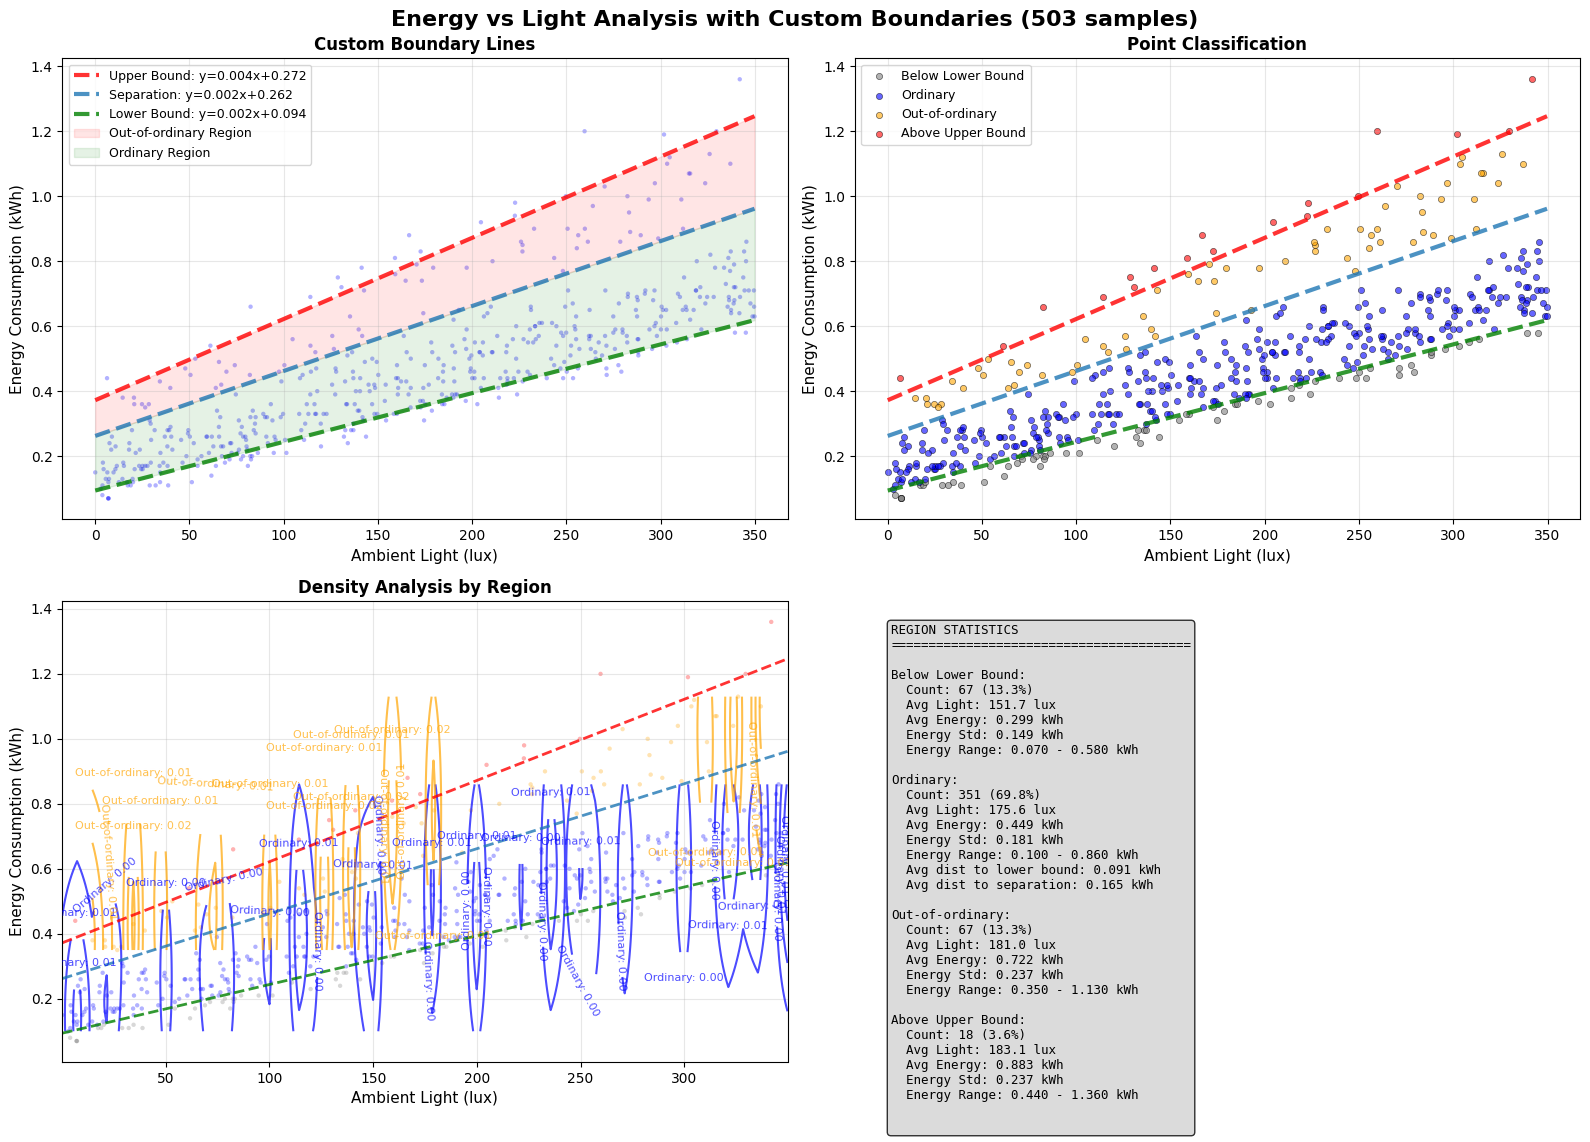


DETAILED BOUNDARY ANALYSIS

CUSTOM BOUNDARY EQUATIONS:
1. Upper Bound:    y = 0.004x + 0.272
2. Separation Line: y = 0.002x + 0.262
3. Lower Bound:    y = 0.002x + 0.094

BOUNDARY STATISTICS AT KEY POINTS:
Light (lux)  Lower Bound   Separation  Upper Bound
       0.1        0.094        0.262        0.372
     173.4        0.354        0.609        0.806
     349.7        0.619        0.961        1.246

REGION CHARACTERISTICS

Summary Statistics by Region:
           Region  Count  Percentage  Avg_Light_lux  Avg_Energy_kWh  Std_Energy_kWh  Min_Energy_kWh  Max_Energy_kWh  Median_Energy_kWh
Below Lower Bound     67      13.320        151.709           0.299           0.149            0.07            0.58              0.280
         Ordinary    351      69.781        175.630           0.449           0.181            0.10            0.86              0.450
  Out-of-ordinary     67      13.320        181.007           0.722           0.237            0.35            1.13              0.7

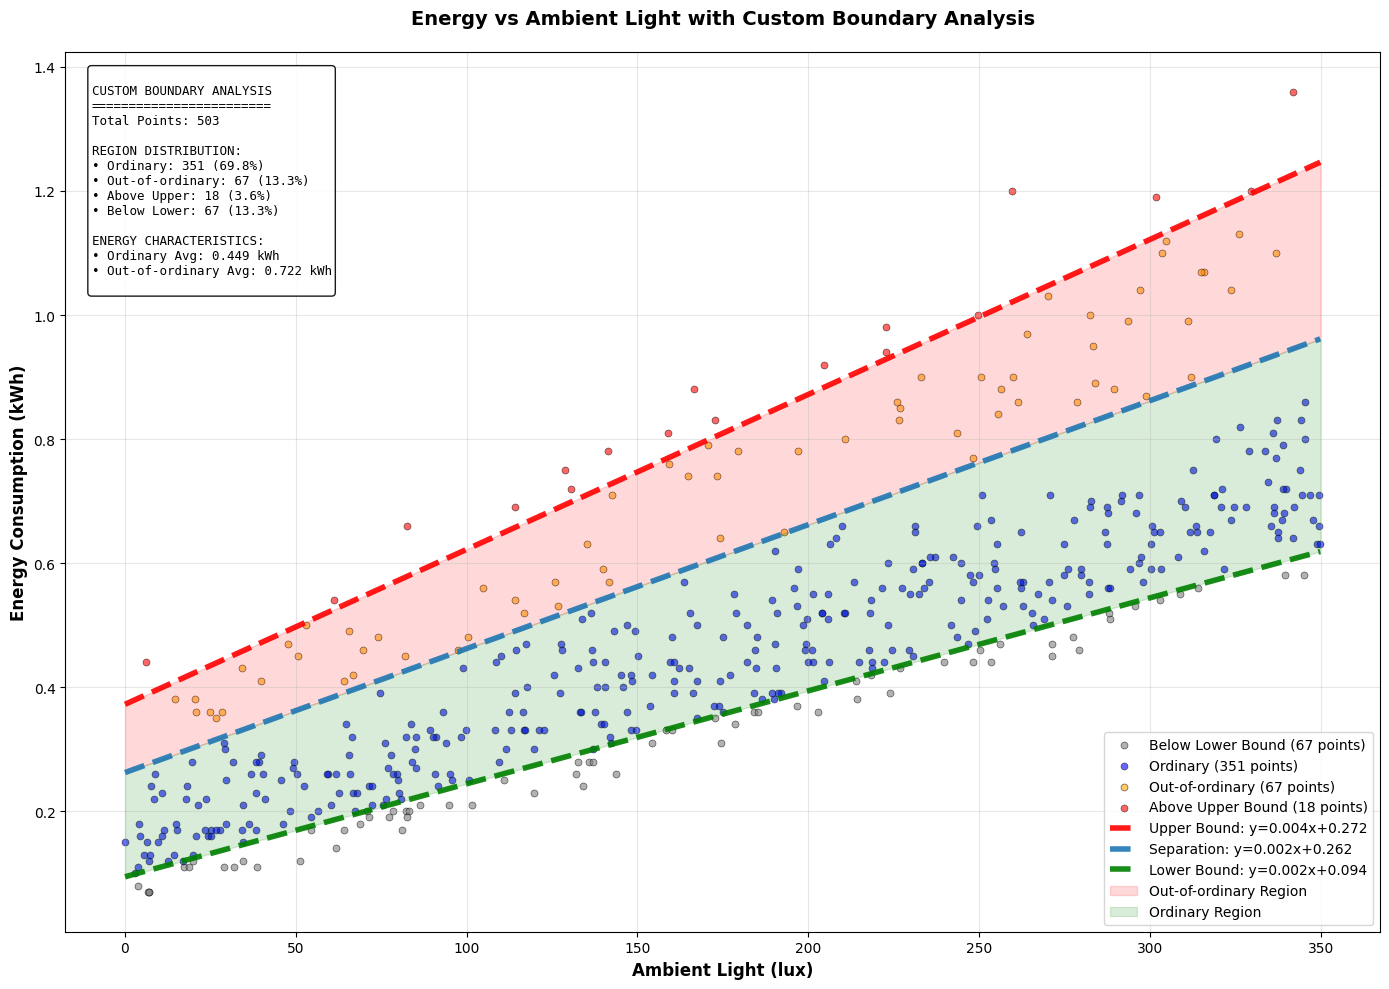

In [174]:
print("="*80)
print("CUSTOM BOUNDARY ANALYSIS")
print("="*80)

# Define your custom boundary equations
def upper_bound(x):
    return 0.0025 * x + 0.372

def separation_line(x):
    return 0.002 * x + 0.262

def lower_bound(x):
    return 0.0015 * x + 0.094

# 1. VISUALIZE WITH CUSTOM BOUNDARIES
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Energy vs Light Analysis with Custom Boundaries ({len(non_zero_energy):,} samples)', 
             fontsize=16, fontweight='bold')

# Plot 1: Scatter with Custom Boundaries
ax1 = axes[0, 0]
scatter1 = ax1.scatter(X, y, alpha=0.3, s=10, c='blue', edgecolors='none')

# Generate x range for boundaries
x_range = np.linspace(X.min(), X.max(), 100)

# Plot boundaries
ax1.plot(x_range, upper_bound(x_range), 'r--', linewidth=3, 
         label='Upper Bound: y=0.004x+0.272', alpha=0.8)
ax1.plot(x_range, separation_line(x_range), '--', linewidth=3, 
         label='Separation: y=0.002x+0.262', alpha=0.8)
ax1.plot(x_range, lower_bound(x_range), 'g--', linewidth=3, 
         label='Lower Bound: y=0.002x+0.094', alpha=0.8)

# Shade regions
ax1.fill_between(x_range, separation_line(x_range), upper_bound(x_range), 
                color='red', alpha=0.1, label='Out-of-ordinary Region')
ax1.fill_between(x_range, lower_bound(x_range), separation_line(x_range), 
                color='green', alpha=0.1, label='Ordinary Region')

ax1.set_title('Custom Boundary Lines', fontsize=12, fontweight='bold')
ax1.set_xlabel('Ambient Light (lux)', fontsize=11)
ax1.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Classify Points
ax2 = axes[0, 1]

# Classify points based on custom boundaries
classifications = []
for x_val, y_val in zip(X.flatten(), y):
    upper_val = upper_bound(x_val)
    sep_val = separation_line(x_val)
    lower_val = lower_bound(x_val)
    
    if y_val > upper_val:
        classification = 3  # Above upper bound
    elif y_val > sep_val:
        classification = 2  # Out-of-ordinary
    elif y_val > lower_val:
        classification = 1  # Ordinary
    else:
        classification = 0  # Below lower bound
    
    classifications.append(classification)

# Define colors and labels
color_map = {0: 'gray', 1: 'blue', 2: 'orange', 3: 'red'}
label_map = {0: 'Below Lower Bound', 1: 'Ordinary', 2: 'Out-of-ordinary', 3: 'Above Upper Bound'}

# Plot classified points
for class_val, color in color_map.items():
    mask = np.array(classifications) == class_val
    if mask.any():
        ax2.scatter(X[mask], y[mask], alpha=0.6, s=20, c=color, 
                   edgecolors='black', linewidth=0.5, label=label_map[class_val])

# Plot boundaries
ax2.plot(x_range, upper_bound(x_range), 'r--', linewidth=3, alpha=0.8)
ax2.plot(x_range, separation_line(x_range), '--', linewidth=3, alpha=0.8)
ax2.plot(x_range, lower_bound(x_range), 'g--', linewidth=3, alpha=0.8)

ax2.set_title('Point Classification', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ambient Light (lux)', fontsize=11)
ax2.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: Density Analysis by Region
ax3 = axes[1, 0]

# Create kernel density estimate for each region
from sklearn.neighbors import KernelDensity

for class_val, color, label in [(1, 'blue', 'Ordinary'), (2, 'orange', 'Out-of-ordinary')]:
    mask = np.array(classifications) == class_val
    if mask.sum() > 10:
        region_x = X[mask].flatten()
        region_y = y[mask]
        
        # Create KDE
        kde = KernelDensity(bandwidth=0.3)
        kde.fit(np.column_stack([region_x, region_y]))
        
        # Create grid
        x_grid = np.linspace(region_x.min(), region_x.max(), 50)
        y_grid = np.linspace(region_y.min(), region_y.max(), 50)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
        positions = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
        
        # Calculate density
        Z = np.exp(kde.score_samples(positions))
        Z = Z.reshape(X_grid.shape)
        
        # Plot contour
        contour = ax3.contour(X_grid, Y_grid, Z, levels=3, colors=color, 
                             linewidths=1.5, alpha=0.7)
        ax3.clabel(contour, inline=True, fontsize=8, fmt=f'{label}: %.2f')

# Plot scatter
for class_val, color in color_map.items():
    mask = np.array(classifications) == class_val
    if mask.any():
        ax3.scatter(X[mask], y[mask], alpha=0.3, s=10, c=color, 
                   edgecolors='none')

# Plot boundaries
ax3.plot(x_range, upper_bound(x_range), 'r--', linewidth=2, alpha=0.8)
ax3.plot(x_range, separation_line(x_range), '--', linewidth=2, alpha=0.8)
ax3.plot(x_range, lower_bound(x_range), 'g--', linewidth=2, alpha=0.8)

ax3.set_title('Density Analysis by Region', fontsize=12, fontweight='bold')
ax3.set_xlabel('Ambient Light (lux)', fontsize=11)
ax3.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax3.grid(True, alpha=0.3)

# Plot 4: Statistical Summary
ax4 = axes[1, 1]
ax4.axis('off')  # Turn off axis for text

# Calculate statistics for each region
stats_text = "REGION STATISTICS\n" + "="*40 + "\n\n"

for class_val, label in sorted(label_map.items()):
    mask = np.array(classifications) == class_val
    count = mask.sum()
    
    if count > 0:
        percentage = count / len(classifications) * 100
        region_x = X[mask]
        region_y = y[mask]
        
        stats_text += f"{label}:\n"
        stats_text += f"  Count: {count:,} ({percentage:.1f}%)\n"
        stats_text += f"  Avg Light: {region_x.mean():.1f} lux\n"
        stats_text += f"  Avg Energy: {region_y.mean():.3f} kWh\n"
        stats_text += f"  Energy Std: {region_y.std():.3f} kWh\n"
        stats_text += f"  Energy Range: {region_y.min():.3f} - {region_y.max():.3f} kWh\n"
        
        # Calculate distance to boundaries
        if class_val == 1:  # Ordinary region
            avg_x = region_x.mean()
            dist_to_lower = region_y.mean() - lower_bound(avg_x)
            dist_to_sep = separation_line(avg_x) - region_y.mean()
            stats_text += f"  Avg dist to lower bound: {dist_to_lower:.3f} kWh\n"
            stats_text += f"  Avg dist to separation: {dist_to_sep:.3f} kWh\n"
        
        stats_text += "\n"

ax4.text(0.05, 0.95, stats_text, fontsize=9, fontfamily='monospace',
         verticalalignment='top', transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# 2. DETAILED STATISTICAL ANALYSIS
print("\n" + "="*80)
print("DETAILED BOUNDARY ANALYSIS")
print("="*80)

print("\nCUSTOM BOUNDARY EQUATIONS:")
print(f"1. Upper Bound:    y = 0.004x + 0.272")
print(f"2. Separation Line: y = 0.002x + 0.262")
print(f"3. Lower Bound:    y = 0.002x + 0.094")

# Calculate boundary statistics
print("\nBOUNDARY STATISTICS AT KEY POINTS:")
key_x_points = [X.min(), X.mean(), X.max()]
print(f"{'Light (lux)':>10} {'Lower Bound':>12} {'Separation':>12} {'Upper Bound':>12}")
for x in key_x_points:
    print(f"{x:10.1f} {lower_bound(x):12.3f} {separation_line(x):12.3f} {upper_bound(x):12.3f}")

# 3. REGION CHARACTERISTICS ANALYSIS
print("\n" + "="*80)
print("REGION CHARACTERISTICS")
print("="*80)

regions_data = []
for class_val, label in label_map.items():
    mask = np.array(classifications) == class_val
    if mask.sum() > 0:
        region_stats = {
            'Region': label,
            'Count': mask.sum(),
            'Percentage': mask.sum() / len(classifications) * 100,
            'Avg_Light_lux': X[mask].mean(),
            'Avg_Energy_kWh': y[mask].mean(),
            'Std_Energy_kWh': y[mask].std(),
            'Min_Energy_kWh': y[mask].min(),
            'Max_Energy_kWh': y[mask].max(),
            'Median_Energy_kWh': np.median(y[mask])
        }
        regions_data.append(region_stats)

regions_df = pd.DataFrame(regions_data)
print("\nSummary Statistics by Region:")
print(regions_df.round(3).to_string(index=False))

# 4. ANALYZE TRANSITION ZONE
print("\n" + "="*80)
print("TRANSITION ZONE ANALYSIS")
print("="*80)

# Define transition zone (near separation line)
transition_width = 0.02  # ±0.02 kWh from separation line
transition_mask = []

for x_val, y_val in zip(X.flatten(), y):
    sep_val = separation_line(x_val)
    if abs(y_val - sep_val) <= transition_width:
        transition_mask.append(True)
    else:
        transition_mask.append(False)

transition_mask = np.array(transition_mask)
transition_count = transition_mask.sum()

print(f"\nTransition Zone (±{transition_width} kWh from separation line):")
print(f"  Points in transition zone: {transition_count:,} ({transition_count/len(y)*100:.1f}%)")
print(f"  Avg distance to separation: {np.mean(np.abs(y[transition_mask] - separation_line(X[transition_mask].flatten()))):.3f} kWh")

# 5. BOUNDARY VIOLATION ANALYSIS
print("\n" + "="*80)
print("BOUNDARY VIOLATION ANALYSIS")
print("="*80)

# Check for violations (points crossing boundaries in unexpected ways)
violations = []

for x_val, y_val, classification in zip(X.flatten(), y, classifications):
    upper_val = upper_bound(x_val)
    lower_val = lower_bound(x_val)
    
    if y_val > upper_val:
        violations.append({
            'Type': 'Above Upper Bound',
            'Distance': y_val - upper_val,
            'x': x_val,
            'y': y_val,
            'Classification': label_map[classification]
        })
    elif y_val < lower_val:
        violations.append({
            'Type': 'Below Lower Bound',
            'Distance': lower_val - y_val,
            'x': x_val,
            'y': y_val,
            'Classification': label_map[classification]
        })

if violations:
    violations_df = pd.DataFrame(violations)
    print(f"\nTotal boundary violations: {len(violations)}")
    print(f"Above Upper Bound: {(violations_df['Type'] == 'Above Upper Bound').sum()}")
    print(f"Below Lower Bound: {(violations_df['Type'] == 'Below Lower Bound').sum()}")
    
    print("\nTop 5 largest violations:")
    print(violations_df.nlargest(5, 'Distance').to_string(index=False))
else:
    print("\nNo boundary violations detected!")

# 6. SAVE CLASSIFICATIONS TO DATA
# Add classifications to data
non_zero_energy['Boundary_Classification'] = [label_map[c] for c in classifications]
non_zero_energy['Boundary_Class_Code'] = classifications

# Calculate distances to boundaries
non_zero_energy['Dist_to_Upper'] = non_zero_energy.apply(
    lambda row: row['Energy Consumption (kWh)'] - upper_bound(row['Ambient Light (lux)']), axis=1
)
non_zero_energy['Dist_to_Separation'] = non_zero_energy.apply(
    lambda row: row['Energy Consumption (kWh)'] - separation_line(row['Ambient Light (lux)']), axis=1
)
non_zero_energy['Dist_to_Lower'] = non_zero_energy.apply(
    lambda row: row['Energy Consumption (kWh)'] - lower_bound(row['Ambient Light (lux)']), axis=1
)

# Calculate which boundary is closest
non_zero_energy['Closest_Boundary'] = non_zero_energy.apply(
    lambda row: min(['Upper', 'Separation', 'Lower'], 
                    key=lambda b: abs(row[f'Dist_to_{b}'])), axis=1
)

# 7. FINAL SUMMARY VISUALIZATION
print("\n" + "="*80)
print("FINAL SUMMARY VISUALIZATION")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 10))

# Plot with enhanced styling
for class_val, color, label in [(0, 'gray', 'Below Lower Bound'),
                                (1, 'blue', 'Ordinary'),
                                (2, 'orange', 'Out-of-ordinary'),
                                (3, 'red', 'Above Upper Bound')]:
    mask = non_zero_energy['Boundary_Class_Code'] == class_val
    if mask.any():
        subset = non_zero_energy[mask]
        ax.scatter(subset['Ambient Light (lux)'], subset['Energy Consumption (kWh)'],
                  alpha=0.6, s=25, c=color, edgecolors='black', linewidth=0.5,
                  label=f'{label} ({mask.sum():,} points)')

# Plot boundaries with enhanced styling
ax.plot(x_range, upper_bound(x_range), 'r--', linewidth=4, alpha=0.9,
        label='Upper Bound: y=0.004x+0.272')
ax.plot(x_range, separation_line(x_range), '--', linewidth=4, alpha=0.9,
        label='Separation: y=0.002x+0.262')
ax.plot(x_range, lower_bound(x_range), 'g--', linewidth=4, alpha=0.9,
        label='Lower Bound: y=0.002x+0.094')

# Add shaded regions with transparency
ax.fill_between(x_range, separation_line(x_range), upper_bound(x_range),
                color='red', alpha=0.15, label='Out-of-ordinary Region')
ax.fill_between(x_range, lower_bound(x_range), separation_line(x_range),
                color='green', alpha=0.15, label='Ordinary Region')

# Add statistics text box
stats_box = f"""
CUSTOM BOUNDARY ANALYSIS
========================
Total Points: {len(non_zero_energy):,}

REGION DISTRIBUTION:
• Ordinary: {(non_zero_energy['Boundary_Class_Code'] == 1).sum():,} ({regions_df[regions_df['Region'] == 'Ordinary']['Percentage'].iloc[0]:.1f}%)
• Out-of-ordinary: {(non_zero_energy['Boundary_Class_Code'] == 2).sum():,} ({regions_df[regions_df['Region'] == 'Out-of-ordinary']['Percentage'].iloc[0]:.1f}%)
• Above Upper: {(non_zero_energy['Boundary_Class_Code'] == 3).sum():,} ({regions_df[regions_df['Region'] == 'Above Upper Bound']['Percentage'].iloc[0]:.1f}%)
• Below Lower: {(non_zero_energy['Boundary_Class_Code'] == 0).sum():,} ({regions_df[regions_df['Region'] == 'Below Lower Bound']['Percentage'].iloc[0]:.1f}%)

ENERGY CHARACTERISTICS:
• Ordinary Avg: {regions_df[regions_df['Region'] == 'Ordinary']['Avg_Energy_kWh'].iloc[0]:.3f} kWh
• Out-of-ordinary Avg: {regions_df[regions_df['Region'] == 'Out-of-ordinary']['Avg_Energy_kWh'].iloc[0]:.3f} kWh
"""

ax.text(0.02, 0.98, stats_box, transform=ax.transAxes, fontsize=9,
        fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_title('Energy vs Ambient Light with Custom Boundary Analysis', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Ambient Light (lux)', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy Consumption (kWh)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ANALYZING 10 STREETS

Color Palette Used for Dim Levels:
  Dim Level 0: #000814
  Dim Level 25: #001d3d
  Dim Level 50: #003566
  Dim Level 75: #ffc300
  Dim Level 100: #ffd60a


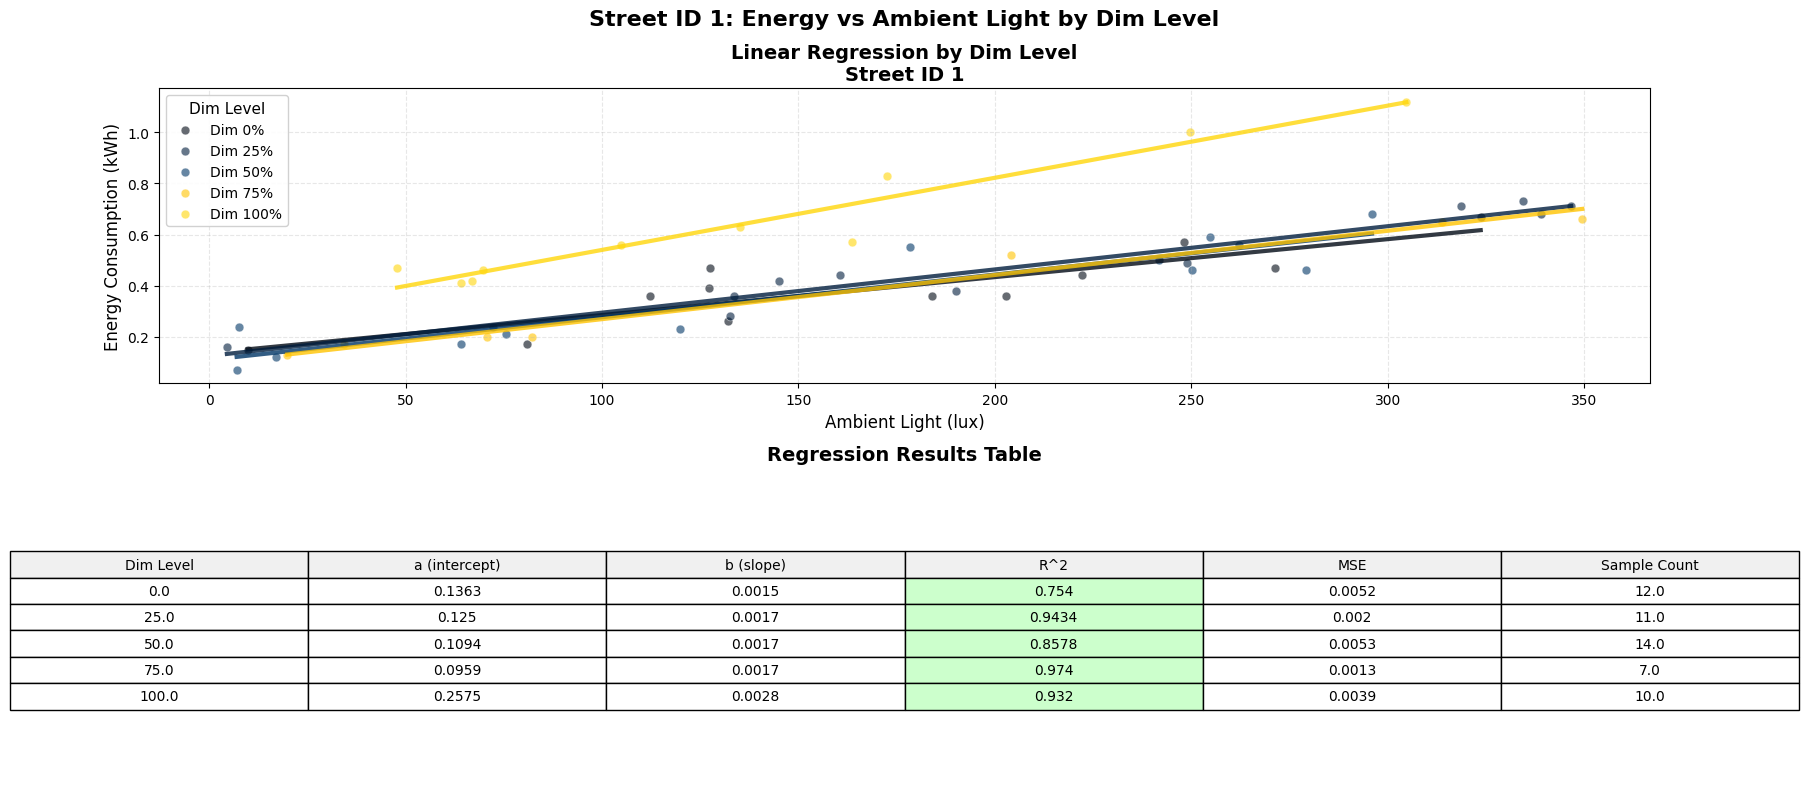

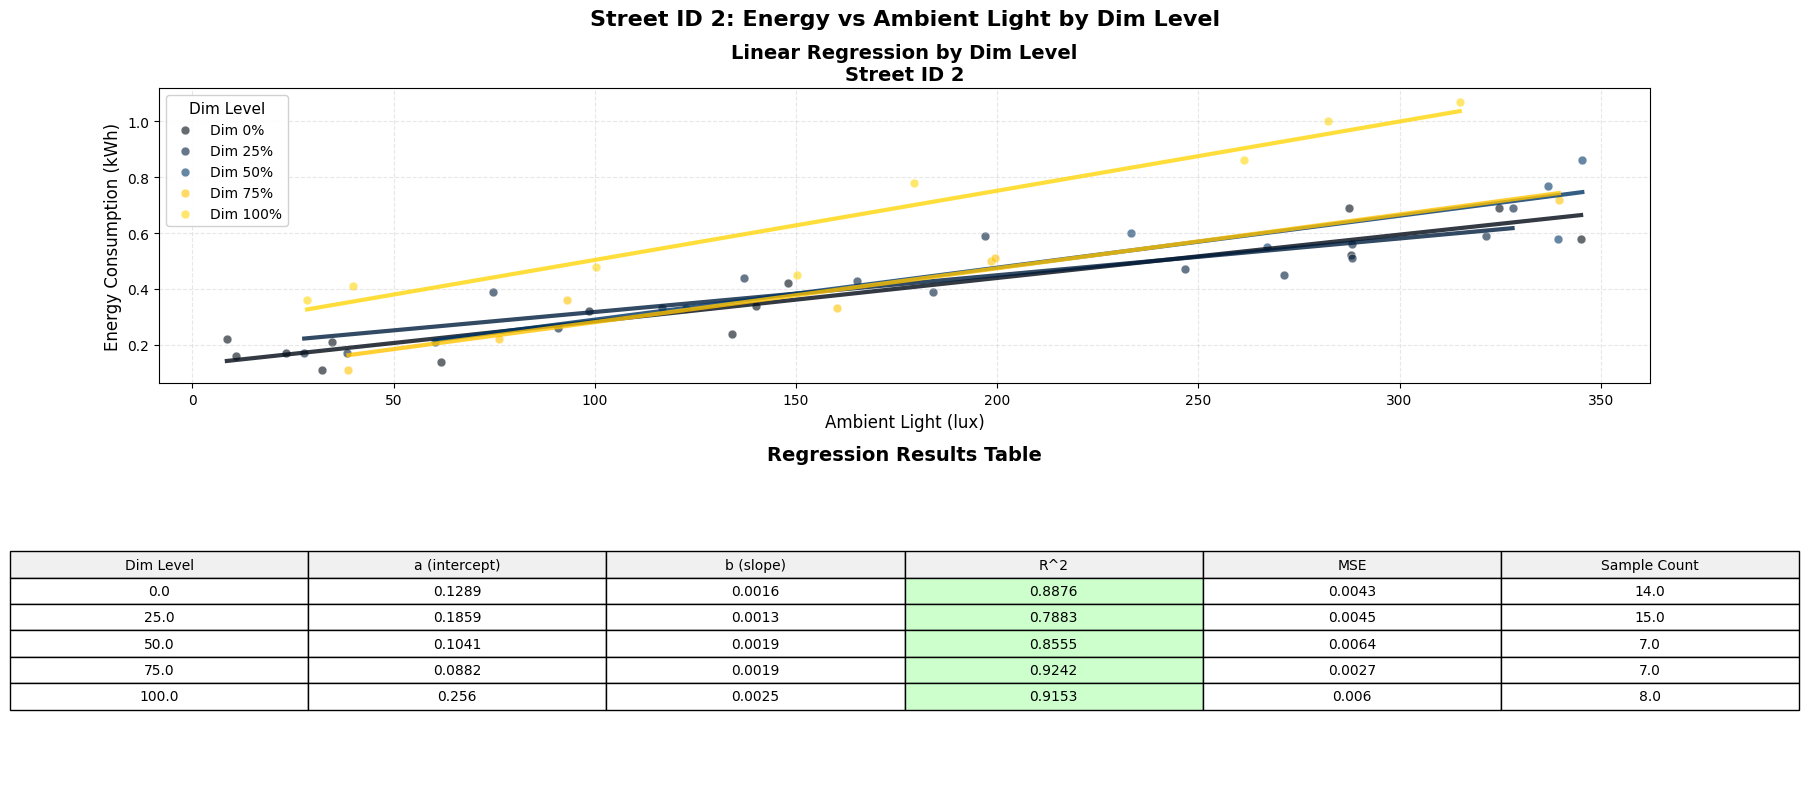

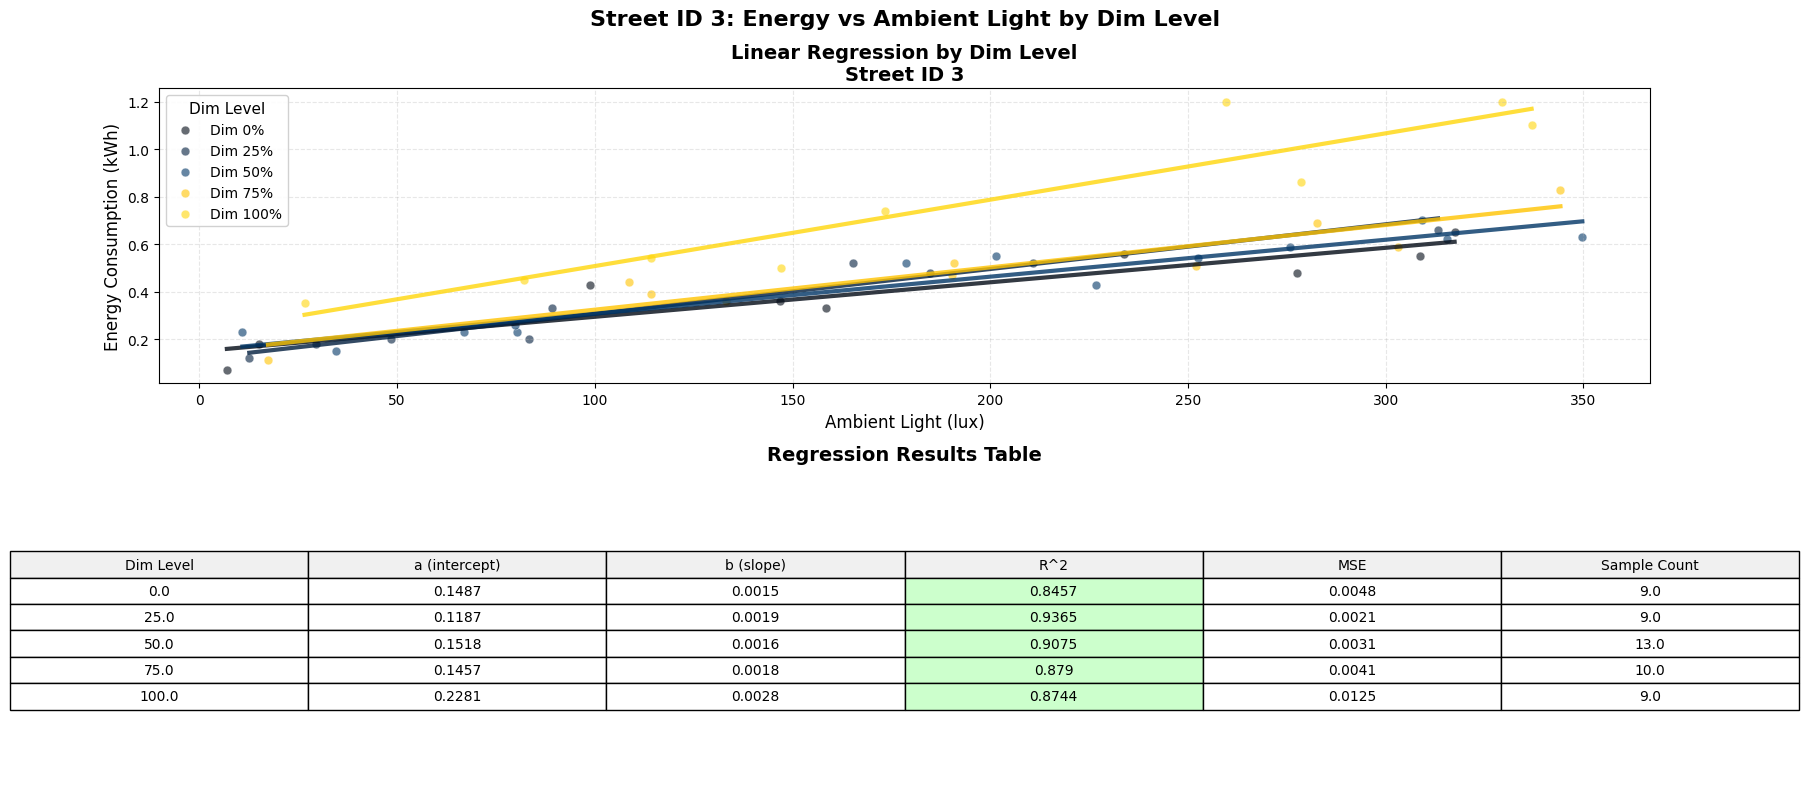

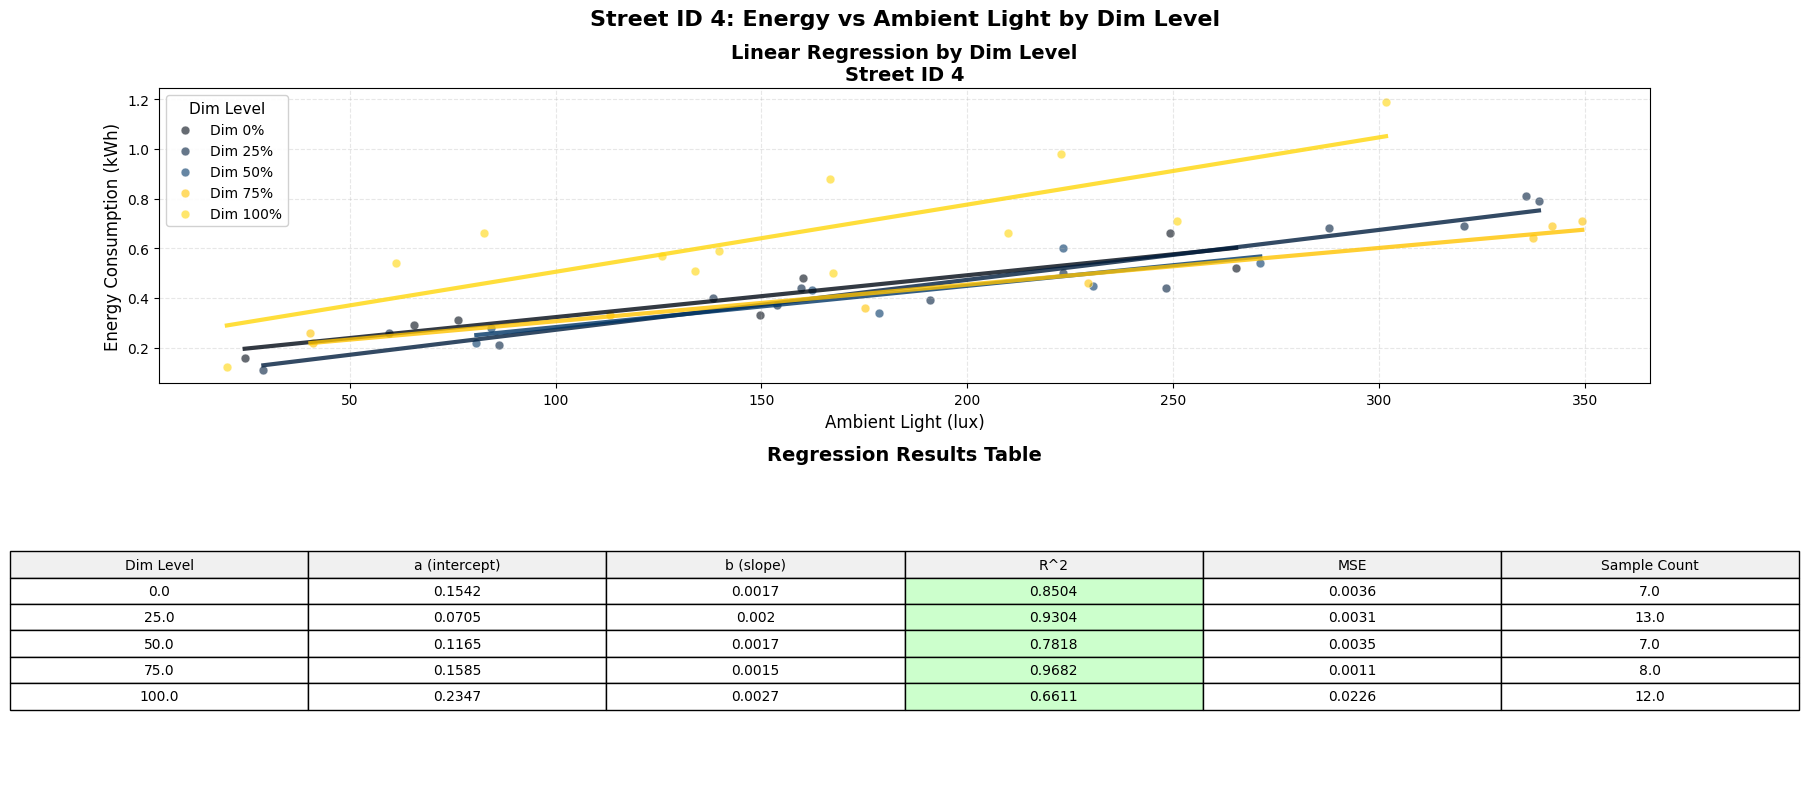

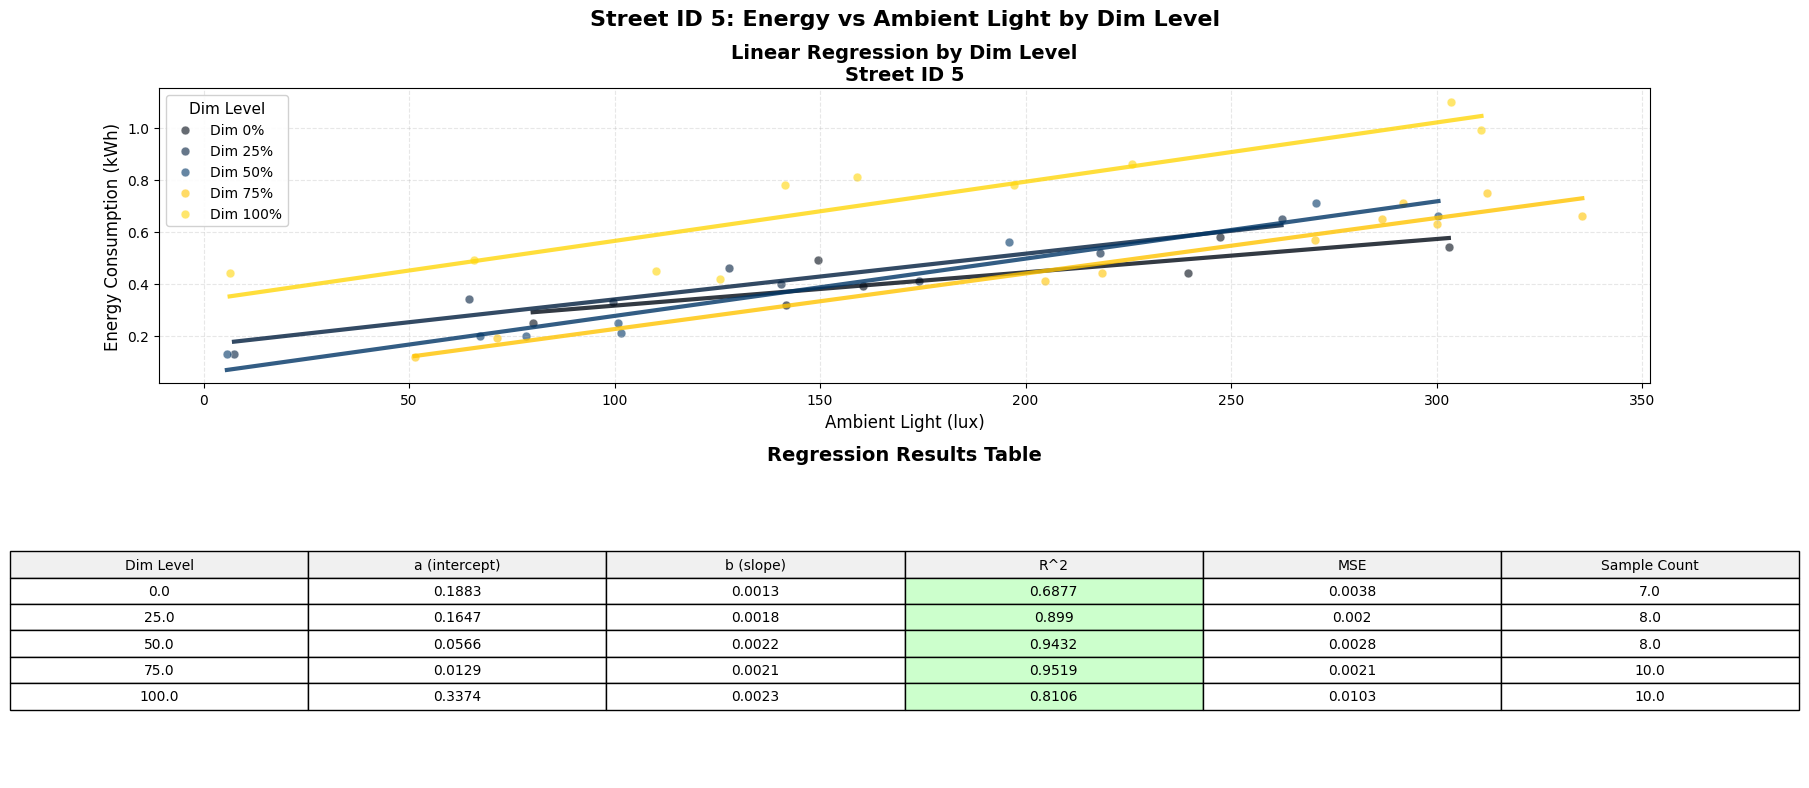

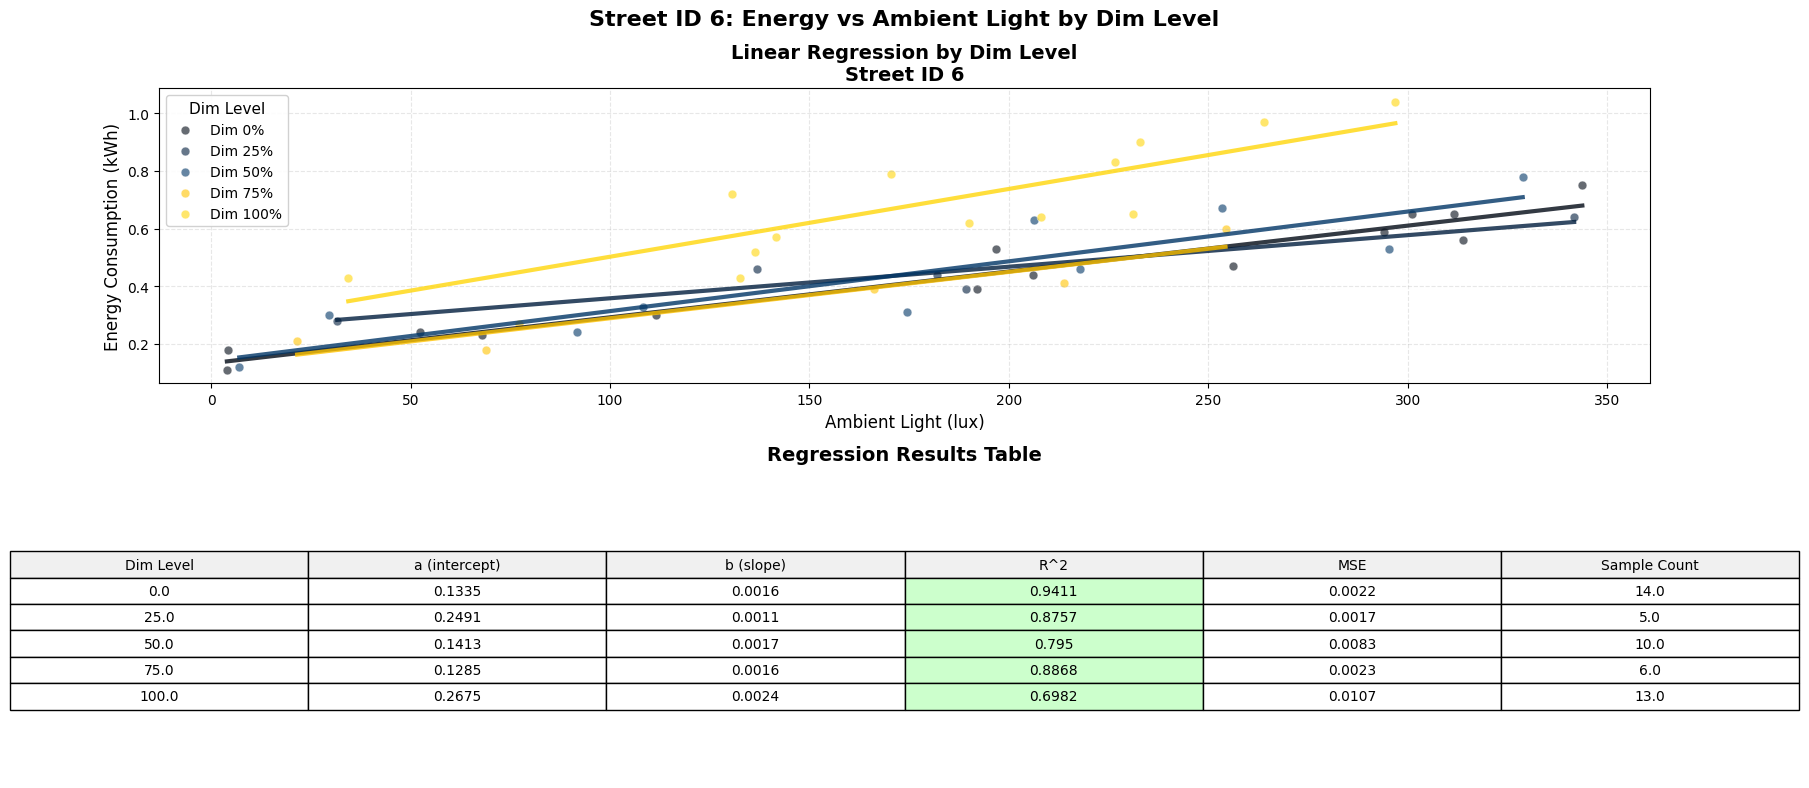

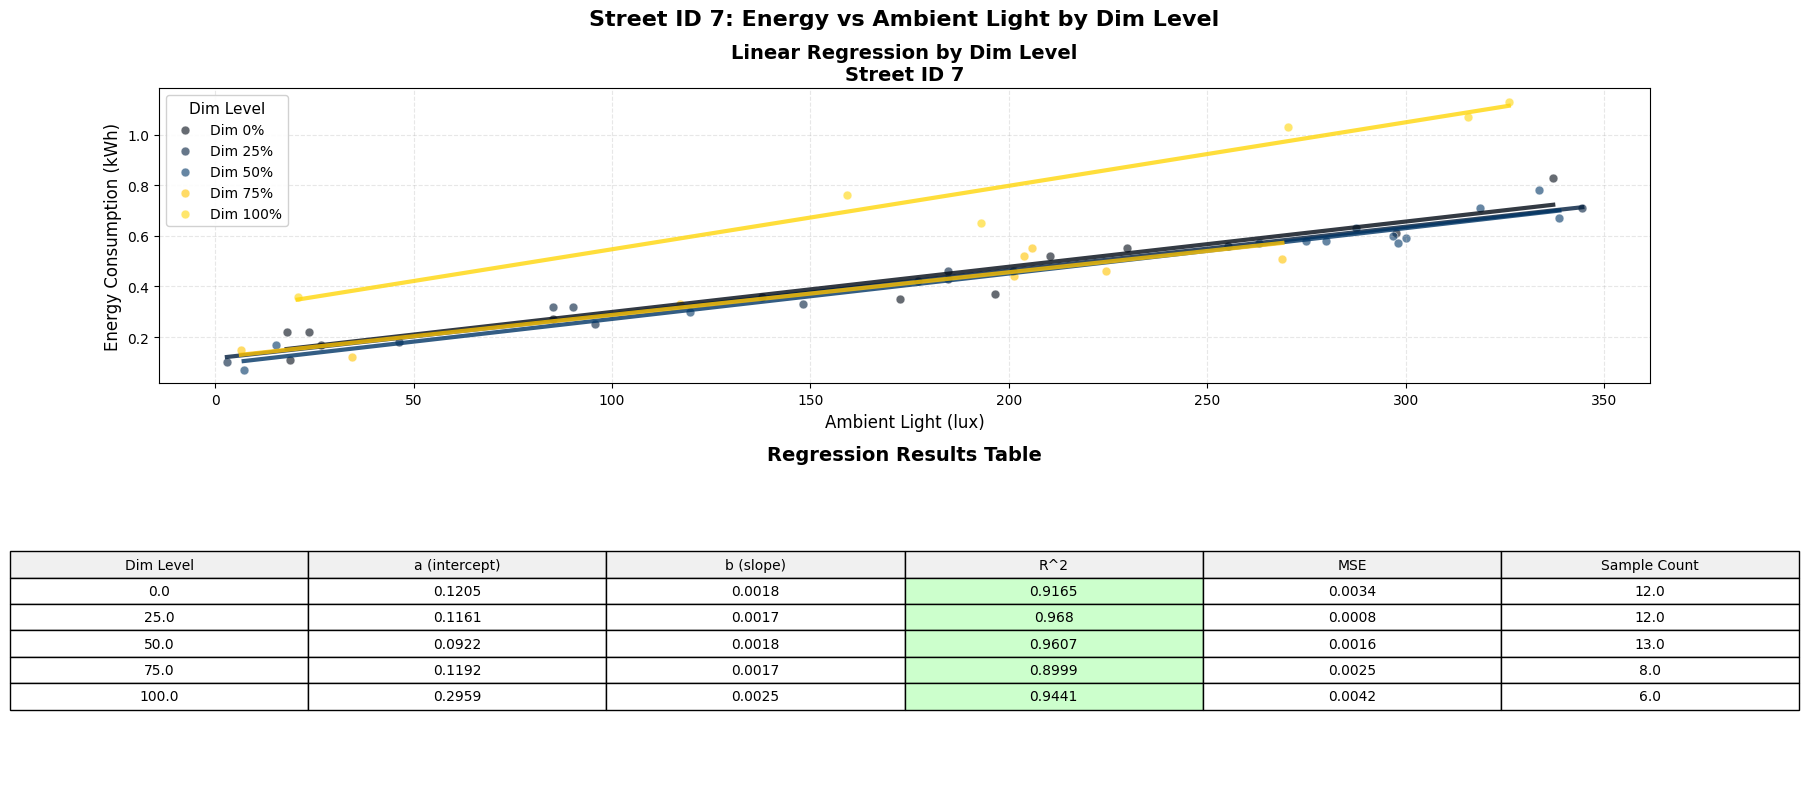

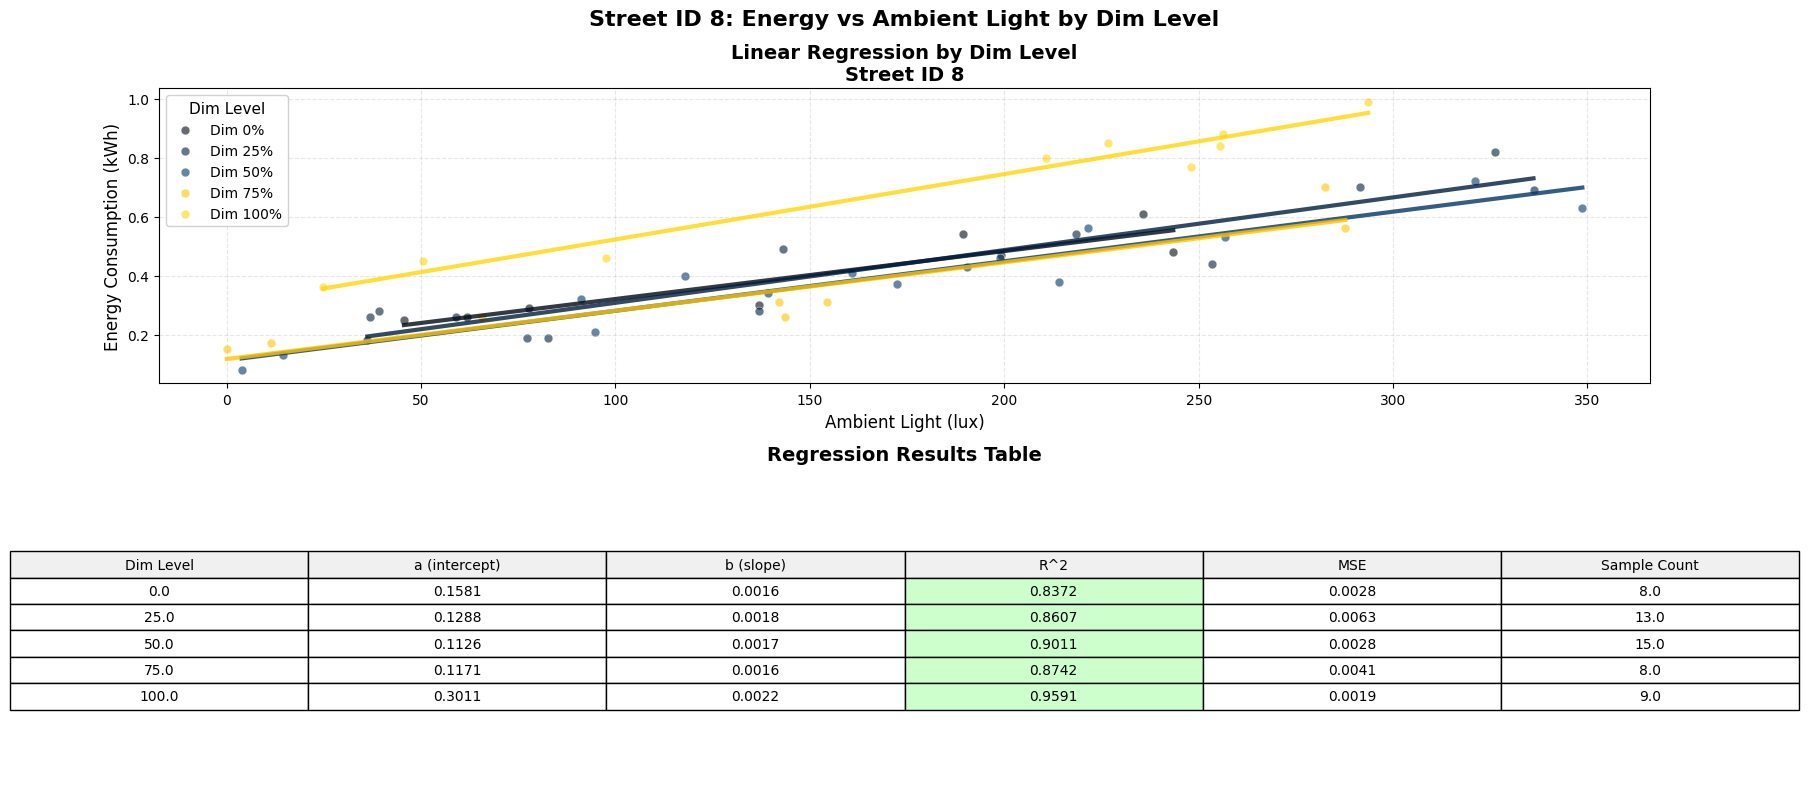

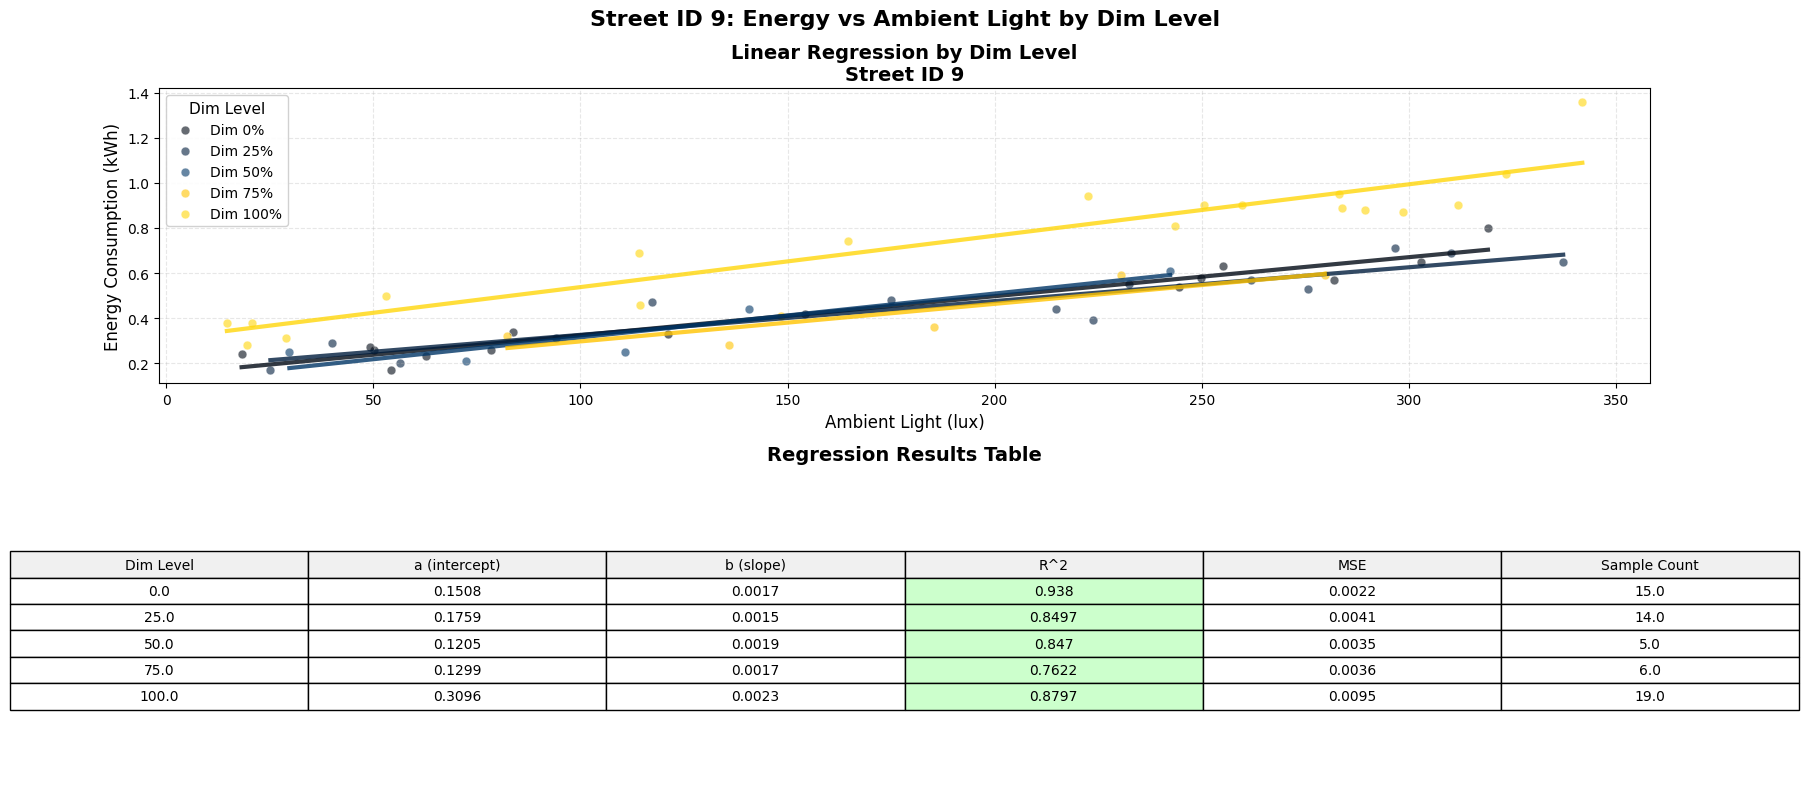

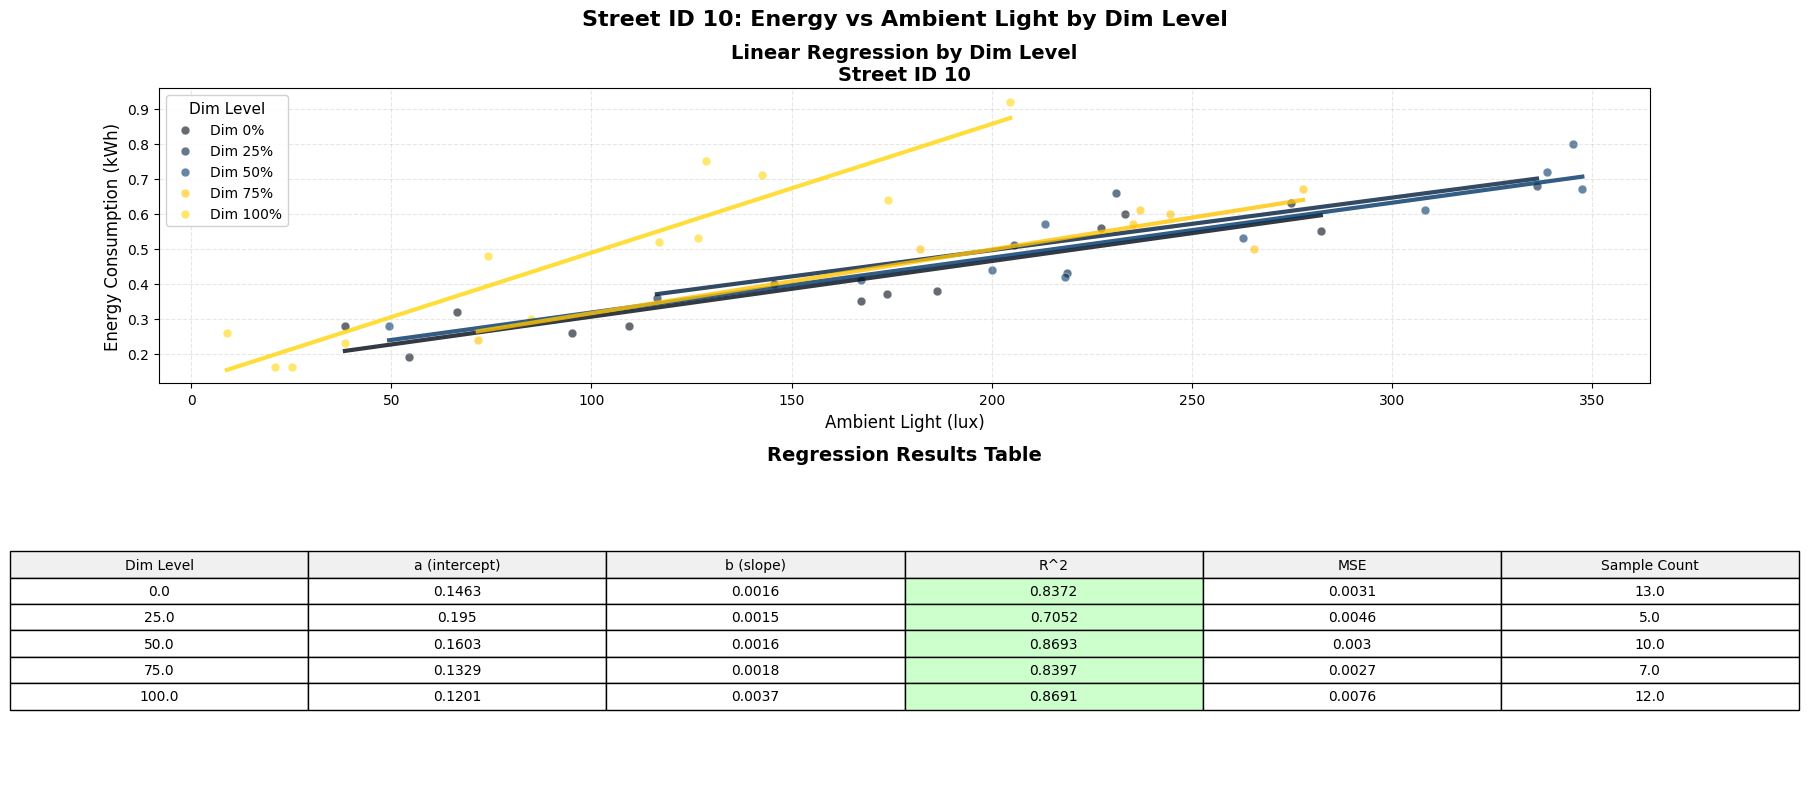


SUMMARY OF REGRESSION ANALYSIS FOR ALL STREETS

Street-wise Summary:
 Street ID  Dim Levels Analyzed  Avg R^2  Avg Slope  Avg Intercept  Total Samples
         1                    5   0.8922     0.0019         0.1448             54
         2                    5   0.8742     0.0018         0.1526             51
         3                    5   0.8886     0.0019         0.1586             50
         4                    5   0.8384     0.0019         0.1469             47
         5                    5   0.8585     0.0019         0.1520             43
         6                    5   0.8394     0.0017         0.1840             48
         7                    5   0.9378     0.0019         0.1488             51
         8                    5   0.8864     0.0018         0.1635             53
         9                    5   0.8553     0.0018         0.1774             59
        10                    5   0.8241     0.0020         0.1509             47

HEATMAP: R^2 VALUES ACROSS 

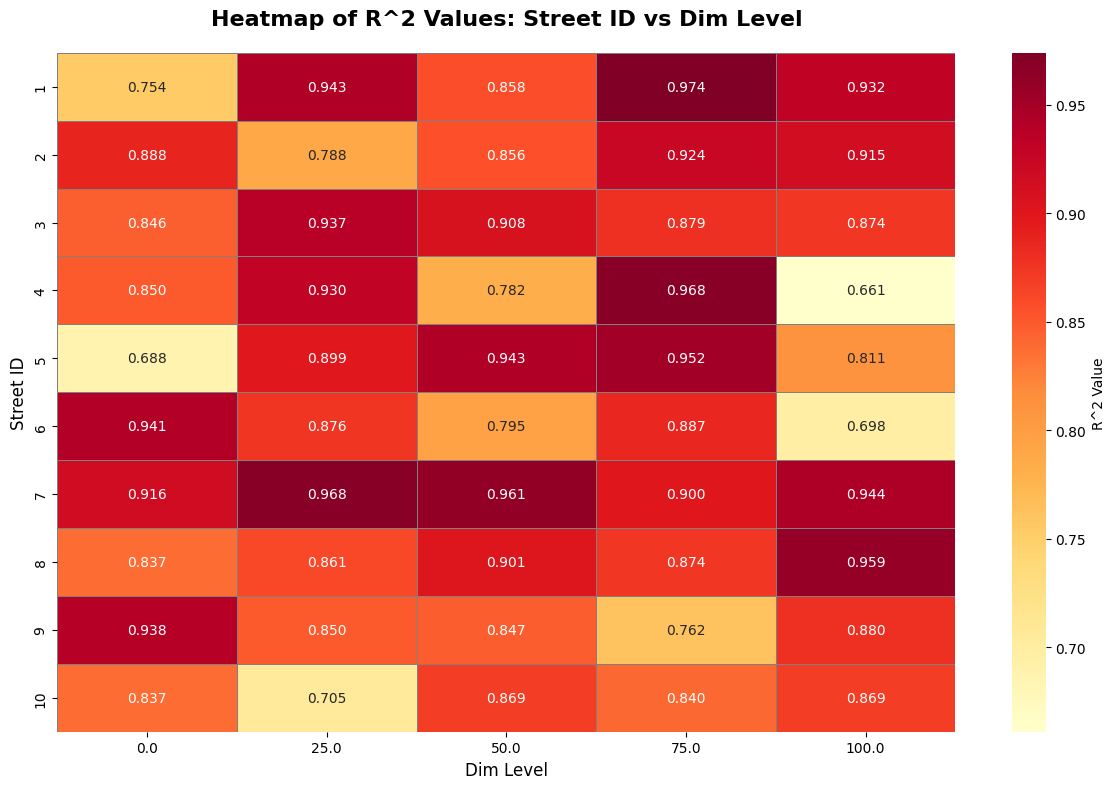


COMBINED REGRESSION TABLE FOR ALL STREETS

Total regression models: 50
 Street ID  Dim Level  a (intercept)  b (slope)    R^2    MSE  Sample Count
         1          0         0.1363     0.0015 0.7540 0.0052            12
         1         25         0.1250     0.0017 0.9434 0.0020            11
         1         50         0.1094     0.0017 0.8578 0.0053            14
         1         75         0.0959     0.0017 0.9740 0.0013             7
         1        100         0.2575     0.0028 0.9320 0.0039            10
         2          0         0.1289     0.0016 0.8876 0.0043            14
         2         25         0.1859     0.0013 0.7883 0.0045            15
         2         50         0.1041     0.0019 0.8555 0.0064             7
         2         75         0.0882     0.0019 0.9242 0.0027             7
         2        100         0.2560     0.0025 0.9153 0.0060             8
         3          0         0.1487     0.0015 0.8457 0.0048             9
         3      

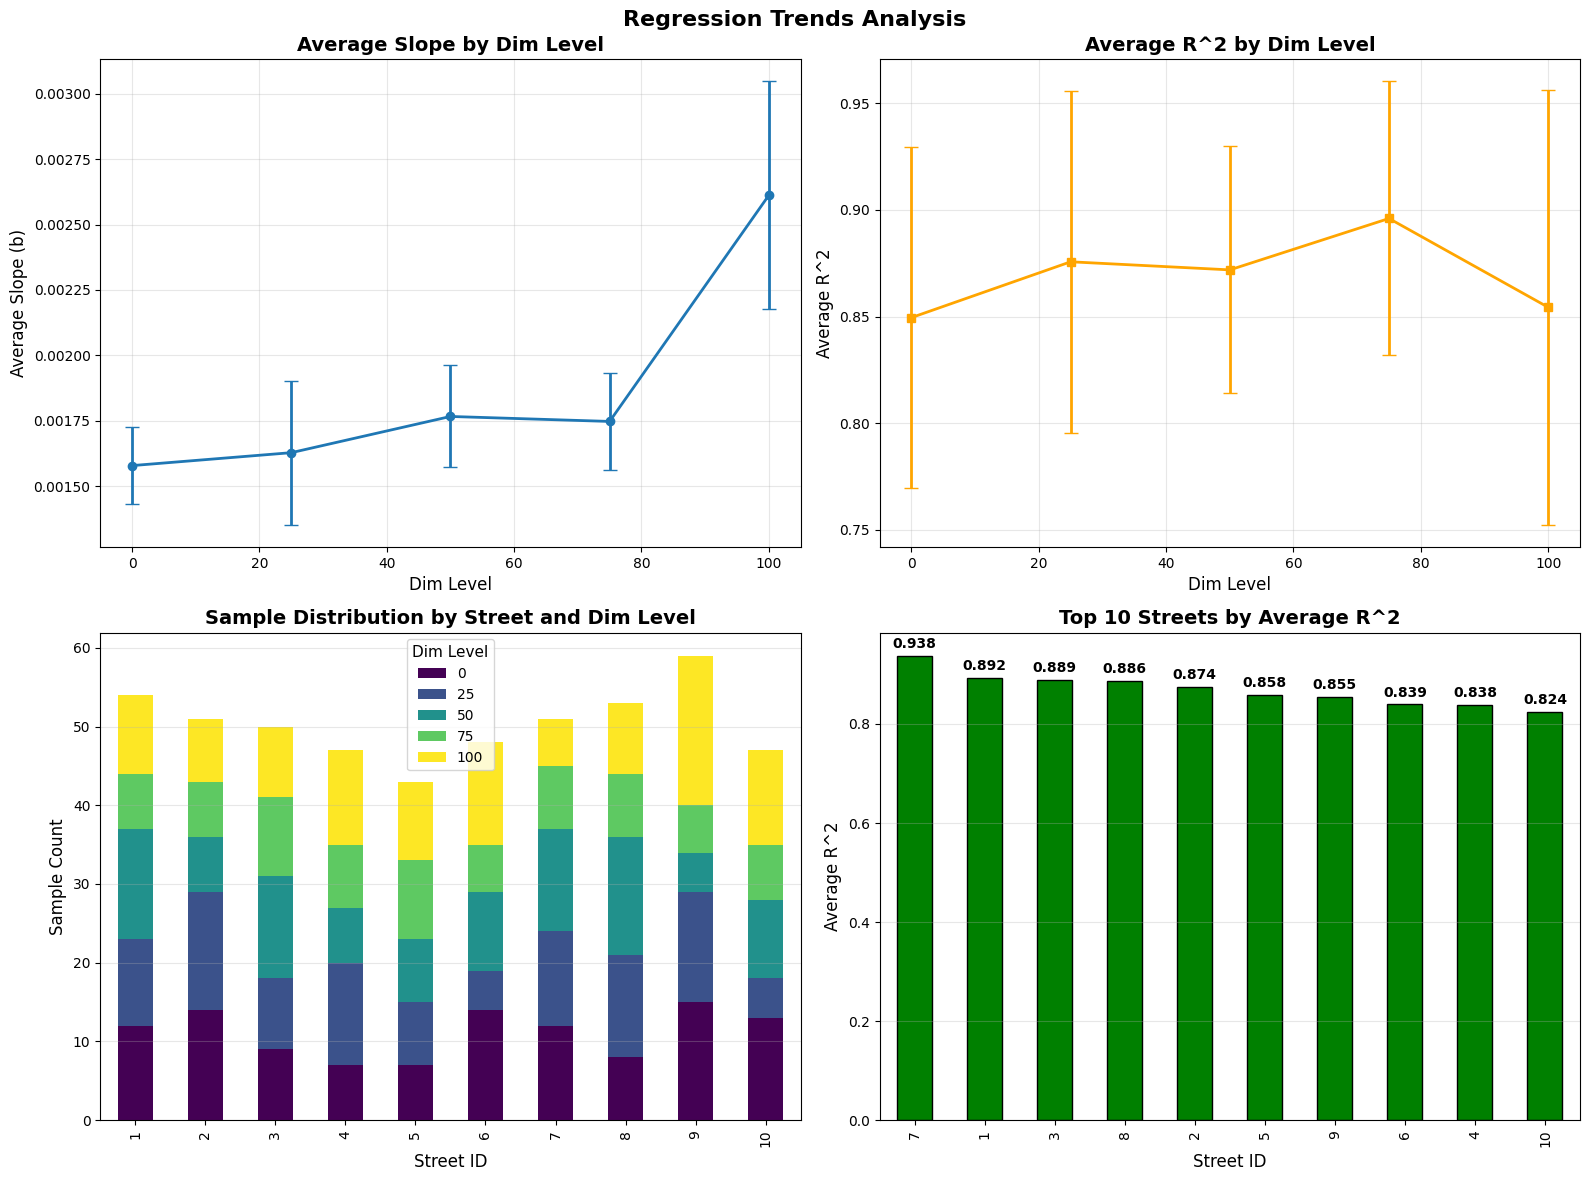

In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define your custom color palette for dim levels
dim_palette = {0: "#000814", 25: "#001d3d", 50: "#003566", 75: "#ffc300", 100: "#ffd60a"}

# Get unique street IDs
street_ids = sorted(non_zero_energy["Street ID"].unique())

print("="*80)
print(f"ANALYZING {len(street_ids)} STREETS")
print("="*80)

# Display color palette used
print("\nColor Palette Used for Dim Levels:")
for dim, color in dim_palette.items():
    print(f"  Dim Level {dim}: {color}")

# Initialize a dictionary to store all regression results
all_regression_results = {}

# Loop through each street ID
for street_id in street_ids:
    # Filter data for this street
    street_data = non_zero_energy[non_zero_energy["Street ID"] == street_id]
    
    # Get unique dim levels present in this street
    dim_levels = sorted(street_data["Dim Level"].unique())
    
    # Skip if not enough data
    if len(street_data) < 10:
        print(f"  Insufficient data ({len(street_data)} samples). Skipping...")
        continue
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8))
    fig.suptitle(f'Street ID {street_id}: Energy vs Ambient Light by Dim Level', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Initialize list to store regression results for this street
    street_regression_results = []
    
    # 1. SCATTER PLOT WITH REGRESSION LINES
    for dim_level in dim_levels:
        # Filter data for this dim level
        dim_data = street_data[street_data["Dim Level"] == dim_level]
        
        if len(dim_data) < 3:  # Need at least 3 points for regression
            continue
        
        # Extract x and y values
        x = dim_data["Ambient Light (lux)"].values.reshape(-1, 1)
        y = dim_data["Energy Consumption (kWh)"].values
        
        # Perform linear regression
        reg = LinearRegression()
        reg.fit(x, y)
        y_pred = reg.predict(x)
        
        # Calculate regression metrics
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        intercept = reg.intercept_
        slope = reg.coef_[0]
        
        # Store results
        result = {
            'Street ID': street_id,
            'Dim Level': dim_level,
            'a (intercept)': intercept,
            'b (slope)': slope,
            'R^2': r2,
            'MSE': mse,
            'Sample Count': len(dim_data)
        }
        street_regression_results.append(result)
        
        # Plot scatter points
        color = dim_palette.get(dim_level, '#808080')  # Default to gray if dim level not in palette
        ax1.scatter(x, y, alpha=0.6, s=40, color=color, 
                   edgecolor='white', linewidth=0.5, label=f'Dim {dim_level}%')
        
        # Plot regression line
        x_line = np.array([[x.min()], [x.max()]])
        y_line = reg.predict(x_line)
        ax1.plot(x_line, y_line, color=color, linewidth=3, linestyle='-', alpha=0.8)
        
        # # Add regression equation as text
        # eq_x = x.min() + (x.max() - x.min()) * 0.1
        # eq_y = y_line[0] + (y_line[1] - y_line[0]) * 0.3
        # eq_text = f'y = {slope:.4f}x + {intercept:.3f}\nR^2 = {r2:.3f}'
        # ax1.text(eq_x, eq_y, eq_text, fontsize=9, fontweight='bold',
        #         bbox=dict(boxstyle='round', facecolor=color, alpha=0.2, edgecolor=color))
    
    # Customize scatter plot
    ax1.set_title(f'Linear Regression by Dim Level\nStreet ID {street_id}', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ambient Light (lux)', fontsize=12)
    ax1.set_ylabel('Energy Consumption (kWh)', fontsize=12)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(title='Dim Level', title_fontsize=11, fontsize=10, 
               loc='upper left', framealpha=0.9)
    
    # 2. CREATE REGRESSION RESULTS TABLE
    if street_regression_results:
        # Create DataFrame for regression results
        reg_df = pd.DataFrame(street_regression_results)
        reg_df = reg_df.sort_values('Dim Level')
        
        # Save to dictionary for later
        all_regression_results[street_id] = reg_df
        
        # Display table as text in subplot
        ax2.axis('tight')
        ax2.axis('off')
        
        # Create table
        table_data = reg_df[['Dim Level', 'a (intercept)', 'b (slope)', 'R^2', 'MSE', 'Sample Count']].copy()
        table_data = table_data.round(4)
        
        # Create table plot
        table = ax2.table(cellText=table_data.values,
                         colLabels=table_data.columns,
                         cellLoc='center',
                         loc='center',
                         colColours=['#f0f0f0']*len(table_data.columns))
        
        # Style the table
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        
        # Color cells based on R^2 value
        for i in range(1, len(table_data) + 1):
            r2_value = table_data.iloc[i-1]['R^2']
            # Color scale from red (low R^2) to green (high R^2)
            if r2_value < 0.3:
                color = '#ffcccc'  # Light red
            elif r2_value < 0.6:
                color = '#fff4cc'  # Light yellow
            else:
                color = '#ccffcc'  # Light green
            
            # Apply color to R^2 cell (column index 3)
            table[(i, 3)].set_facecolor(color)
        
        ax2.set_title('Regression Results Table', fontsize=14, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

# 3. CREATE SUMMARY TABLE FOR ALL STREETS
print("\n" + "="*80)
print("SUMMARY OF REGRESSION ANALYSIS FOR ALL STREETS")
print("="*80)

# Combine all regression results into one DataFrame
all_results_list = []
for street_id, reg_df in all_regression_results.items():
    # Add average metrics for each street
    street_summary = {
        'Street ID': street_id,
        'Dim Levels Analyzed': len(reg_df),
        'Avg R^2': reg_df['R^2'].mean(),
        'Avg Slope': reg_df['b (slope)'].mean(),
        'Avg Intercept': reg_df['a (intercept)'].mean(),
        'Total Samples': reg_df['Sample Count'].sum()
    }
    all_results_list.append(street_summary)

if all_results_list:
    summary_df = pd.DataFrame(all_results_list)
    summary_df = summary_df.sort_values('Street ID')
    
    # Display summary
    print("\nStreet-wise Summary:")
    print(summary_df.round(4).to_string(index=False))
    
    # 4. CREATE HEATMAP OF R^2 VALUES ACROSS STREETS
    print("\n" + "="*80)
    print("HEATMAP: R^2 VALUES ACROSS STREETS AND DIM LEVELS")
    print("="*80)
    
    # Create pivot table for heatmap
    heatmap_data = []
    for street_id, reg_df in all_regression_results.items():
        for _, row in reg_df.iterrows():
            heatmap_data.append({
                'Street ID': street_id,
                'Dim Level': row['Dim Level'],
                'R^2': row['R^2']
            })
    
    if heatmap_data:
        heatmap_df = pd.DataFrame(heatmap_data)
        pivot_table = heatmap_df.pivot(index='Street ID', columns='Dim Level', values='R^2')
        
        # Plot heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', 
                    cbar_kws={'label': 'R^2 Value'}, linewidths=0.5, linecolor='gray')
        plt.title('Heatmap of R^2 Values: Street ID vs Dim Level', 
                  fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Dim Level', fontsize=12)
        plt.ylabel('Street ID', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # 5. CREATE COMBINED REGRESSION TABLE
    print("\n" + "="*80)
    print("COMBINED REGRESSION TABLE FOR ALL STREETS")
    print("="*80)
    
    # Combine all individual regression results
    combined_results = pd.concat(all_regression_results.values(), ignore_index=True)
    combined_results = combined_results.sort_values(['Street ID', 'Dim Level'])
    
    # Display combined table
    display_cols = ['Street ID', 'Dim Level', 'a (intercept)', 'b (slope)', 'R^2', 'MSE', 'Sample Count']
    print(f"\nTotal regression models: {len(combined_results)}")
    print(combined_results[display_cols].round(4).head(20).to_string(index=False))
    
    # 6. STATISTICAL ANALYSIS OF REGRESSION COEFFICIENTS
    print("\n" + "="*80)
    print("STATISTICAL ANALYSIS OF REGRESSION COEFFICIENTS")
    print("="*80)
    
    # Analyze slope distribution
    print("\nSlope (b) Distribution:")
    print(f"  Mean slope: {combined_results['b (slope)'].mean():.6f}")
    print(f"  Std deviation: {combined_results['b (slope)'].std():.6f}")
    print(f"  Min slope: {combined_results['b (slope)'].min():.6f}")
    print(f"  Max slope: {combined_results['b (slope)'].max():.6f}")
    
    # Analyze R^2 distribution
    print("\nR^2 Distribution:")
    print(f"  Mean R^2: {combined_results['R^2'].mean():.4f}")
    print(f"  Std deviation: {combined_results['R^2'].std():.4f}")
    
    # Count good fits (R^2 > 0.7)
    good_fits = combined_results[combined_results['R^2'] > 0.7]
    print(f"  Models with R^2 > 0.7: {len(good_fits)} ({len(good_fits)/len(combined_results)*100:.1f}%)")
    
    # 7. CREATE TREND VISUALIZATION
    print("\n" + "="*80)
    print("TREND VISUALIZATION: SLOPE AND R^2 BY DIM LEVEL")
    print("="*80)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Regression Trends Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Average slope by dim level
    ax1 = axes[0, 0]
    slope_by_dim = combined_results.groupby('Dim Level')['b (slope)'].agg(['mean', 'std', 'count'])
    ax1.errorbar(slope_by_dim.index, slope_by_dim['mean'], 
                yerr=slope_by_dim['std'], fmt='o-', capsize=5, linewidth=2)
    ax1.set_title('Average Slope by Dim Level', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Dim Level', fontsize=12)
    ax1.set_ylabel('Average Slope (b)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Average R^2 by dim level
    ax2 = axes[0, 1]
    r2_by_dim = combined_results.groupby('Dim Level')['R^2'].agg(['mean', 'std'])
    ax2.errorbar(r2_by_dim.index, r2_by_dim['mean'], 
                yerr=r2_by_dim['std'], fmt='s-', capsize=5, linewidth=2, color='orange')
    ax2.set_title('Average R^2 by Dim Level', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Dim Level', fontsize=12)
    ax2.set_ylabel('Average R^2', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Sample count by street and dim level
    ax3 = axes[1, 0]
    sample_counts = combined_results.pivot(index='Street ID', columns='Dim Level', values='Sample Count')
    sample_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='viridis')
    ax3.set_title('Sample Distribution by Street and Dim Level', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Street ID', fontsize=12)
    ax3.set_ylabel('Sample Count', fontsize=12)
    ax3.legend(title='Dim Level', title_fontsize=11, fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Best performing streets (highest avg R^2)
    ax4 = axes[1, 1]
    street_performance = combined_results.groupby('Street ID')['R^2'].mean().sort_values(ascending=False).head(10)
    street_performance.plot(kind='bar', ax=ax4, color='green', edgecolor='black')
    ax4.set_title('Top 10 Streets by Average R^2', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Street ID', fontsize=12)
    ax4.set_ylabel('Average R^2', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, v in enumerate(street_performance):
        ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
